<a href="https://colab.research.google.com/github/Erjg1012/predicciones/blob/main/Prediccion_de_aceptaci%C3%B3n_de_prestamos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación binaria con modelos lineales y discriminantes

PROBLEMÁTICA DEL PROYECTO:
Este conjunto de datos proviene de una campaña de marketing de un banco portugués. Sin embargo, contactar a todos los clientes genera un alto costo y no garantiza resultados. El objetivo del proyecto es construir modelos de clasificación que permitan predecir si un cliente aceptará o no una oferta de depósito bancario.

Objetivos del modelo:

* Reducir costos de campaña al contactar solo a clientes con alta probabilidad de aceptación.
* Identificar perfiles de clientes más propensos a responder positivamente.
* Mejorar la toma de decisiones mediante un sistema basado en datos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import zscore

In [ ]:
# Cargar datos
file_path = "bank-additional-full.csv"
df = pd.read_csv(file_path, sep=';')
df["y"] = df["y"].map({"yes": 1, "no": 0})
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 5.9+ MB


,age,balance,day,duration,campaign,pdays,previous,y
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,0.116985
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


Eliminación de la columna duration. Esta columna contiene la duración de la llamada, que generalmente puede causar sesgo en modelos predictivos, ya que suele estar correlacionada con el objetivo (la respuesta "y").

Codificación de la variable objetivo "y": Estás mapeando la variable objetivo y para que las respuestas 'yes' se conviertan en 1 y 'no' en 0. Esto es importante, ya que muchos modelos de clasificación trabajan con variables numéricas.

In [ ]:
# Análisis exploratorio

# Renombrar columnas para facilitar su interpretación
rename_dict = {
    'age': 'edad',
    'job': 'tipo_trabajo',
    'marital': 'estado_civil',
    'education': 'nivel_educativo',
    'default': 'credito_incumplido',
    'housing': 'prestamo_vivienda',
    'loan': 'prestamo_personal',
    'contact': 'tipo_contacto',
    'month': 'mes_contacto',
    'day_of_week': 'dia_semana',
    'duration': 'duracion_llamada',
    'campaign': 'contactos_actuales',
    'pdays': 'dias_ultimo_contacto',
    'previous': 'contactos_previos',
    'poutcome': 'resultado_camp_prev',
    'emp.var.rate': 'variacion_empleo',
    'cons.price.idx': 'indice_precios',
    'cons.conf.idx': 'indice_confianza',
    'euribor3m': 'tasa_euribor3m',
    'nr.employed': 'num_empleados',
    'y': 'deposito_aceptado'
}

df.rename(columns=rename_dict, inplace=True)
cat_cols = ['tipo_trabajo','estado_civil','nivel_educativo','credito_incumplido','prestamo_vivienda','prestamo_personal','tipo_contacto','mes_contacto','dia_semana','resultado_camp_prev']
num_cols = ['edad','contactos_actuales','dias_ultimo_contacto','contactos_previos','variacion_empleo','indice_precios','indice_confianza','tasa_euribor3m','num_empleados','duracion_llamada']
from tabulate import tabulate

print("\n\nResumen de variables numéricas: n")
print(tabulate(df[num_cols].describe().T, headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

print("\n\nDistribución de la variable objetivo (%): \n")
y_counts = df['deposito_aceptado'].value_counts(normalize=True).rename({0: 'No', 1: 'Sí'}) * 100
print(tabulate(y_counts.reset_index().rename(columns={'index': 'Clase', 'y': 'Porcentaje'}), headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

print("\n\nValores únicos por variable categórica: \n")
for col in cat_cols:
    print(f"{col}: {sorted(df[col].unique())}")



Resumen de variables numéricas: n


KeyError: "['variacion_empleo', 'indice_precios', 'indice_confianza', 'tasa_euribor3m', 'num_empleados'] not in index"

Resumen de variables numéricas:
Edad (age): La edad media de los clientes es de 40.02 años, con un mínimo de 17 años y un máximo de 98 años. Esto sugiere que hay clientes de una amplia gama de edades, pero la mayoría están entre los 30 y 50 años.

Número de contactos en esta campaña (campaign): El número promedio de contactos por cliente en esta campaña es 2.57, con un máximo de 56. Esto indica que la mayoría de los clientes han sido contactados pocas veces, pero algunos recibieron un número elevado de contactos.

Último contacto (pdays): El valor medio es 962.48, pero el valor mínimo es 0, lo que sugiere que muchos clientes no han sido contactados previamente, ya que el valor 999 parece indicar que no se realizó contacto previo.

Número de contactos previos (previous): La mayoría de los clientes tienen pocos contactos previos, ya que la media es 0.17.

Tasas de variación del empleo (emp.var.rate): Esta variable muestra una baja variabilidad, con un promedio de 0.08, indicando que la tasa de variación del empleo no ha tenido grandes fluctuaciones.

Índices de precio y confianza: El cons.price.idx tiene un promedio de 93.58, lo que sugiere que los precios no han variado mucho, y el cons.conf.idx tiene un promedio negativo de -40.50, lo que indica una baja confianza del consumidor.

Otros índices como euribor3m y nr.employed están dentro de rangos esperados.

2. Distribución de la variable objetivo (y):
Distribución de las clases: La variable y tiene un 88.73% de clientes que no aceptaron la oferta ("No"), y un 11.27% que la aceptaron ("Sí").

Desbalance de clases: Esto indica que las clases están bastante desbalanceadas, con muchas más instancias de la clase "No". Este desbalance es importante para los modelos de clasificación, ya que algunos algoritmos pueden estar sesgados hacia la clase mayoritaria (en este caso "No").

3. Valores únicos por variable categórica:
Trabajo (job): Los valores únicos en la columna job incluyen categorías como "admin.", "blue-collar", "housemaid", "entrepreneur", etc., lo que refleja que hay una variedad de tipos de trabajo en el dataset.

Estado civil (marital): Los clientes se dividen en categorías como "divorced", "married", "single", etc.

Educación (education): Hay una gran diversidad en los niveles educativos, incluyendo "basic.4y", "high.school", "university.degree", etc.

Otros campos: También observamos otras variables categóricas como default, housing, loan, contact, etc., que reflejan si el cliente tiene ciertas condiciones de crédito, si tiene un préstamo, o cómo fue contactado, entre otros.



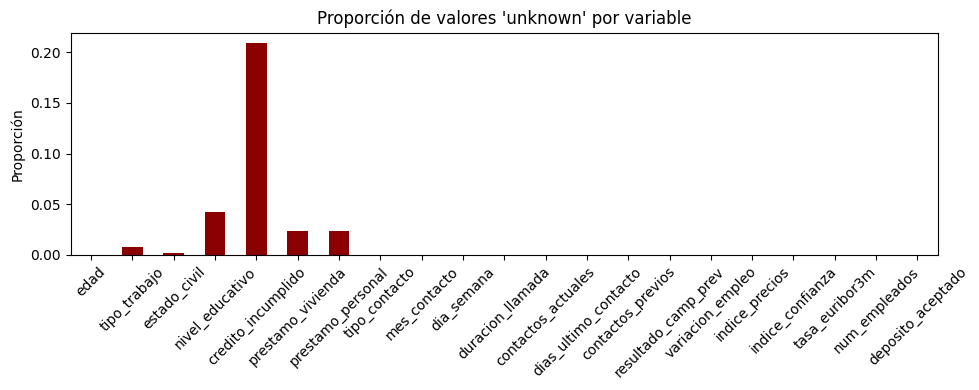

In [ ]:
# Visualización de valores faltantes codificados como 'unknown'
plt.figure(figsize=(10,4))
(df == 'unknown').mean().plot(kind='bar', color='darkred')
plt.title("Proporción de valores 'unknown' por variable")
plt.ylabel("Proporción")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Valores 'unknown': Este gráfico identifica qué tan frecuentes son los valores 'unknown' en las columnas del dataset. Se observa que algunas variables tienen una proporción considerable de valores 'unknown', especialmente la variable default (casi 20% de los valores son 'unknown'), lo que podría indicar datos faltantes o categorías no definidas por los clientes.

Variables afectadas: Además de default, también hay valores 'unknown' en las columnas education, housing, loan, etc., lo que sugiere que podría haber muchos datos faltantes o categorías no especificadas en estas variables.

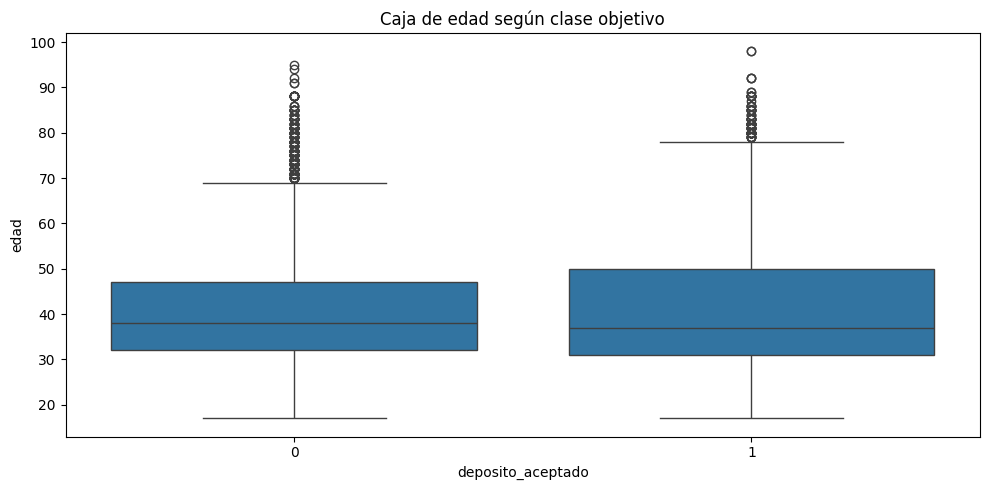

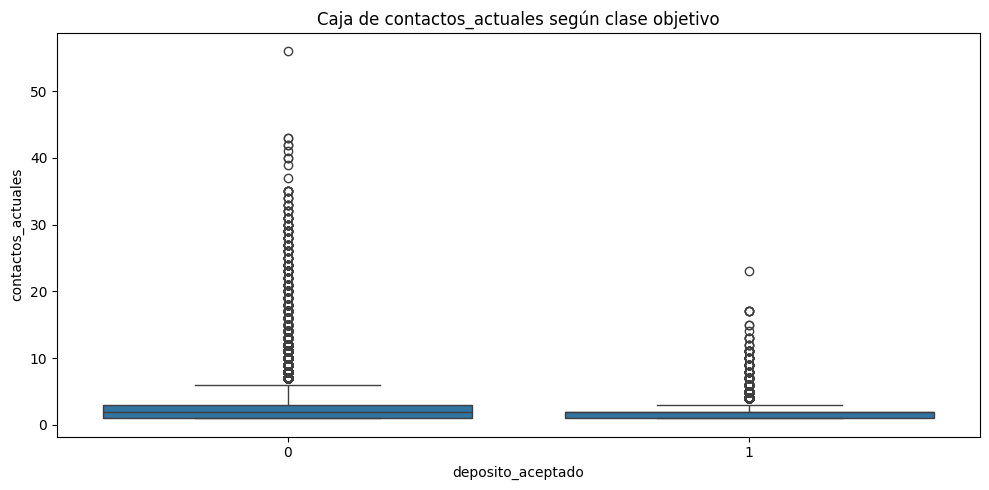

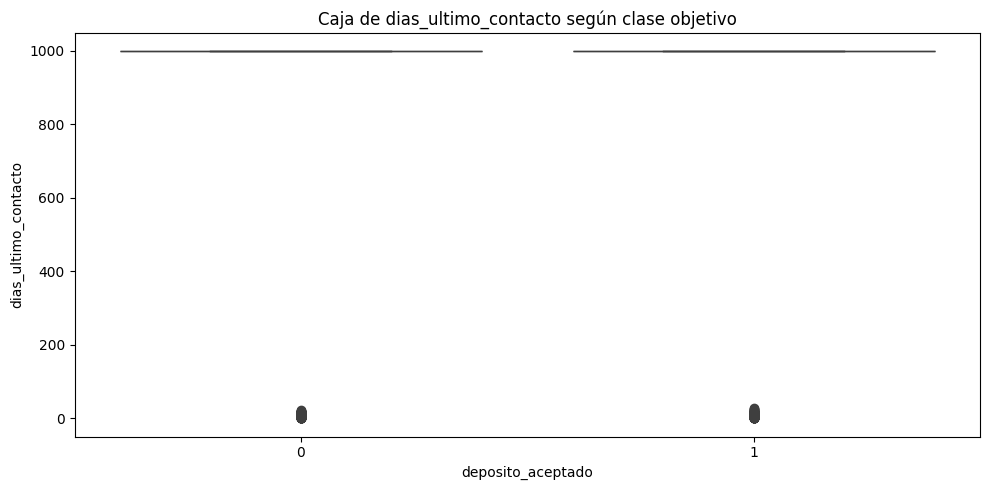

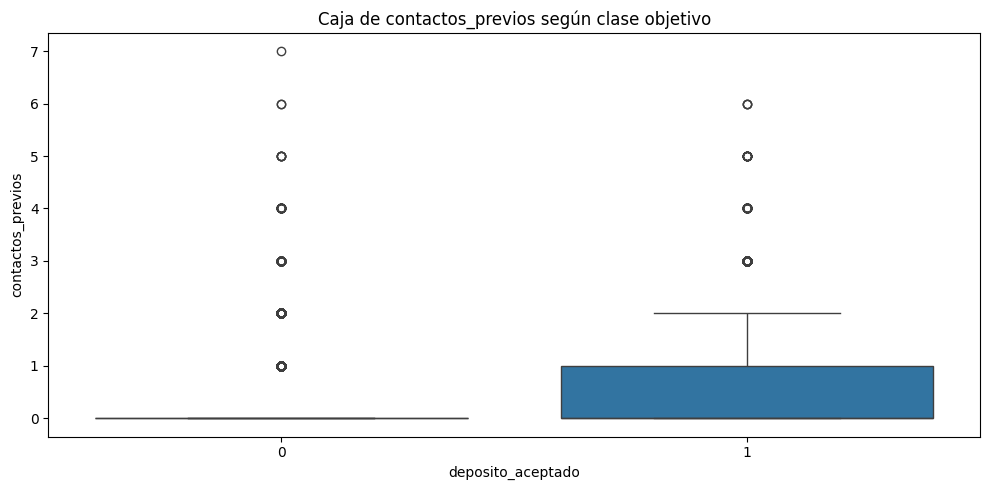

In [ ]:
# Visualizaciones EDA con boxplots para distribución de variables numéricas
for col in ["edad", "contactos_actuales", "dias_ultimo_contacto", "contactos_previos"]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="deposito_aceptado", y=col, data=df)
    plt.title(f"Caja de {col} según clase objetivo")
    plt.tight_layout()
    plt.show()

Caja de age según clase objetivo:
Clase 0 (No aceptó la oferta): La edad media parece estar alrededor de 40 años, con algunos valores atípicos en el rango superior (por encima de los 70 años).

Clase 1 (Sí aceptó la oferta): La mayoría de los clientes que aceptaron la oferta tienen una edad media más baja, cerca de 40 años también, pero con algunos valores atípicos.

Conclusión: Aunque no hay una gran diferencia visual entre las edades de las dos clases, parece que los clientes más jóvenes (menos de 30) tienen más probabilidades de aceptar la oferta.

2. Caja de campaign según clase objetivo:
Clase 0: El número de contactos en la campaña es bajo para la mayoría de los clientes, con muchos valores en el rango 0-5. Existen varios valores atípicos con más de 30 contactos, lo que podría indicar que algunos clientes recibieron más llamadas.

Clase 1: Los clientes que aceptaron la oferta recibieron menos contactos en la campaña en comparación con los de clase 0. La mayoría de los valores están cerca de 0 o 1.

Conclusión: La relación entre la variable campaign y la clase objetivo indica que, generalmente, los clientes que aceptaron la oferta recibieron menos contactos, lo que podría sugerir que no es necesario contactar a un cliente muchas veces para que acepte la oferta.

3. Caja de pdays según clase objetivo:
Clase 0: La mayoría de los valores en pdays son 999, lo que indica que muchos clientes nunca fueron contactados en campañas anteriores.

Clase 1: Para los clientes que aceptaron la oferta, la variable pdays también está mayormente en 999, lo que indica que, en su mayoría, no fueron contactados anteriormente.

Conclusión: Aunque muchos valores de pdays son 999, parece que los contactos previos no afectan significativamente la decisión de aceptar la oferta, ya que la distribución es similar entre las dos clases.

4. Caja de previous según clase objetivo:
Clase 0: La mayoría de los clientes de esta clase no tienen contacto previo (valor cercano a 0), pero hay algunos que tienen valores más altos, lo que indica que algunas personas recibieron muchos contactos previos.

Clase 1: Los clientes que aceptaron la oferta tienden a haber tenido al menos un contacto previo, ya que la mediana está por encima de 0.

Conclusión: Los clientes que aceptaron la oferta generalmente han tenido más contactos previos que los que no aceptaron. Esto puede indicar que la interacción previa tiene un impacto positivo en la aceptación de la oferta.

Resumen:
Edad: No hay una gran diferencia en la edad entre las dos clases, aunque los más jóvenes tienden a aceptar más la oferta.

Campaign: Los clientes que aceptan la oferta generalmente reciben menos contactos.

Pdays: La variable pdays muestra que muchos clientes no fueron contactados previamente, pero no parece influir en la aceptación.

Previous: Los clientes que aceptan la oferta han sido contactados previamente más que aquellos que no la aceptan.

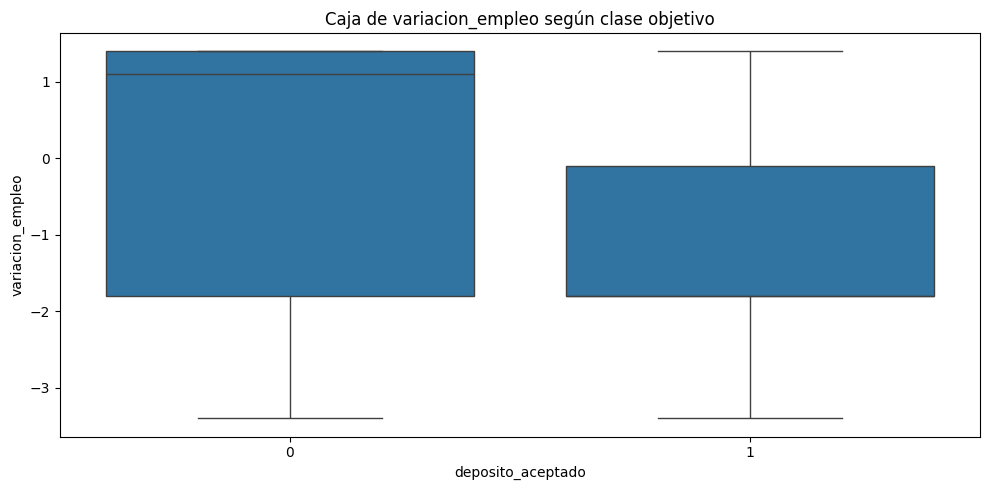

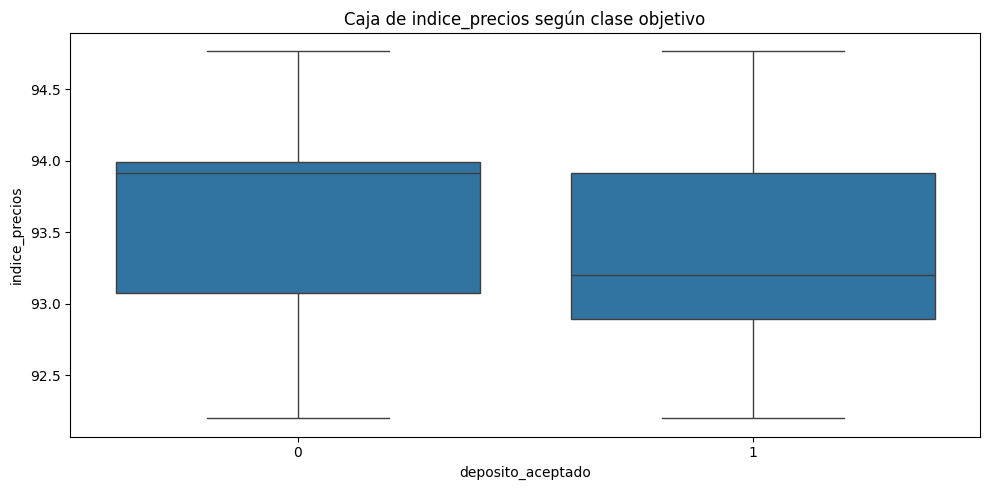

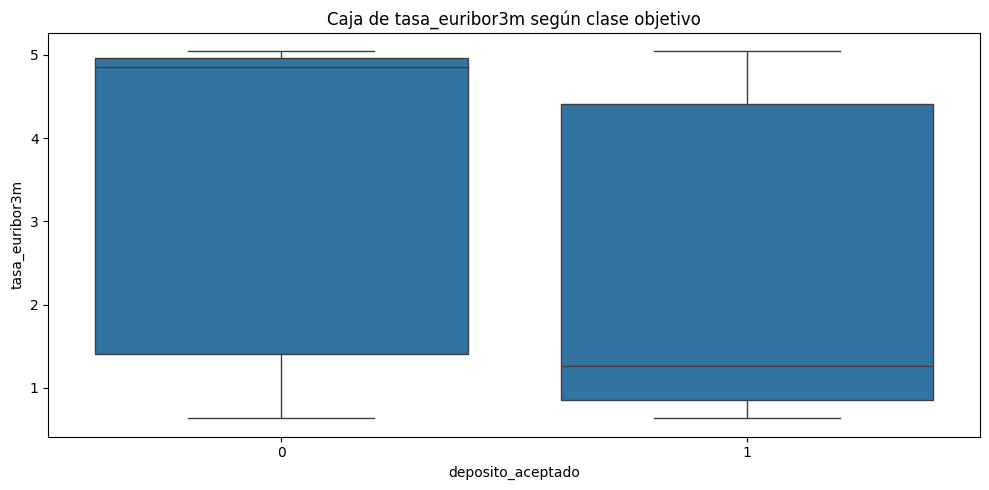

In [ ]:
for col in ["variacion_empleo", "indice_precios", "tasa_euribor3m"]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="deposito_aceptado", y=col, data=df)
    plt.title(f"Caja de {col} según clase objetivo")
    plt.tight_layout()
    plt.show()

1. Caja de emp.var.rate según clase objetivo:
Clase 0 (No aceptó la oferta): La mayoría de los valores de emp.var.rate están concentrados alrededor de 1.0, lo que sugiere una estabilidad en la tasa de variación del empleo entre aquellos que no aceptaron la oferta.

Clase 1 (Sí aceptó la oferta): La mayoría de los valores también están cerca de 1.0, pero con algo más de dispersión en torno a la media.

Conclusión: No parece haber una gran diferencia en la tasa de variación del empleo entre las clases. Los valores son bastante similares, lo que sugiere que esta variable no influye significativamente en la aceptación de la oferta.

2. Caja de cons.price.idx según clase objetivo:
Clase 0 (No aceptó la oferta): Los valores de cons.price.idx están centrados alrededor de 93.9, con poca variación.

Clase 1 (Sí aceptó la oferta): Los valores de cons.price.idx están igualmente concentrados en torno a 93.9, pero muestran una ligera tendencia a estar más bajos para los clientes que aceptaron la oferta.

Conclusión: La variable cons.price.idx no parece tener un impacto significativo sobre la clase objetivo. La distribución es similar entre las dos clases, con una ligera diferencia en las medias.

3. Caja de euribor3m según clase objetivo:
Clase 0 (No aceptó la oferta): Los valores de euribor3m están distribuidos principalmente entre 2.0 y 5.0, con una mediana cercana a 4.8.

Clase 1 (Sí aceptó la oferta): Los clientes que aceptaron la oferta tienden a tener valores de euribor3m más bajos, con una mediana más cercana a 2.5.

Conclusión: La variable euribor3m parece tener un efecto notable en la aceptación de la oferta. Los clientes que aceptaron la oferta tienden a estar en un entorno de tasas de interés más bajas, lo que podría indicar que las condiciones económicas tienen un impacto sobre la decisión de aceptar la oferta.

Resumen:
emp.var.rate y cons.price.idx no muestran diferencias notables entre las clases, lo que sugiere que no tienen un impacto importante en la decisión de aceptar la oferta.

euribor3m muestra una diferencia más clara, ya que los clientes que aceptaron la oferta parecen estar más expuestos a tasas de interés más bajas.

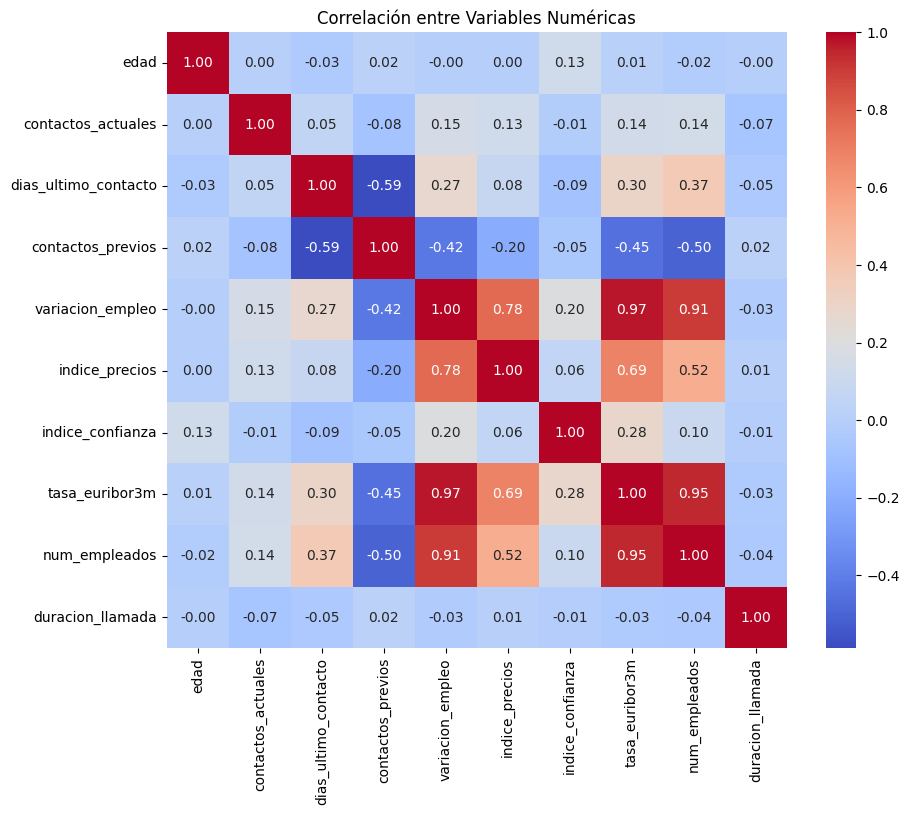

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlación entre Variables Numéricas")
plt.show()

Variables altamente correlacionadas:

emp.var.rate y euribor3m: Tienen una correlación muy alta de 0.97. Esto sugiere que ambas variables están fuertemente relacionadas, probablemente debido a que ambos indicadores reflejan factores macroeconómicos que afectan las tasas de interés y la variabilidad económica.

emp.var.rate y nr.employed: Correlación de 0.91, lo que indica que cuando hay más empleados (indicador de nr.employed), también tiende a haber una mayor variabilidad en la tasa de empleo (indicador de emp.var.rate).

euribor3m y nr.employed: Correlación de 0.95, lo que sugiere que las tasas de interés a 3 meses (euribor3m) están estrechamente relacionadas con el número de empleados, posiblemente porque ambas reflejan el estado de la economía.

Variables con baja correlación:

age y campaign: La correlación es muy baja (0.00), lo que significa que no hay una relación lineal entre la edad del cliente y el número de contactos realizados en la campaña.

age y previous: Correlación de 0.02, indicando que no hay una relación entre la edad y el número de contactos previos.

campaign y previous: Correlación de -0.59, lo que muestra que generalmente, si un cliente ha tenido muchos contactos previos, tiene menos probabilidades de ser contactado en la campaña actual (esto puede reflejar un enfoque de contacto más selectivo o estratégico).

Relaciones importantes a considerar:

previous y emp.var.rate: Correlación de -0.42, lo que sugiere que los clientes con más contactos previos tienden a tener menores valores en la tasa de variación del empleo, lo que podría indicar que ciertos clientes con un historial más largo de contacto tienen menos probabilidades de estar en un entorno económico favorable.

cons.price.idx y emp.var.rate: La correlación positiva de 0.78 muestra que cuando los precios al consumidor son más altos, generalmente hay más variabilidad en la tasa de empleo, lo que refleja la influencia de los precios en el mercado laboral.

Resumen:
Las variables macroeconómicas (emp.var.rate, euribor3m, nr.employed) están fuertemente correlacionadas, lo que indica que se mueven en conjunto y reflejan el estado de la economía.

Las variables de contacto como campaign, previous, y pdays muestran algunas relaciones, pero no tienen una fuerte correlación con las variables macroeconómicas.

Las variables de edad (age) y los indicadores de contacto (como campaign y previous) no parecen estar muy relacionadas.

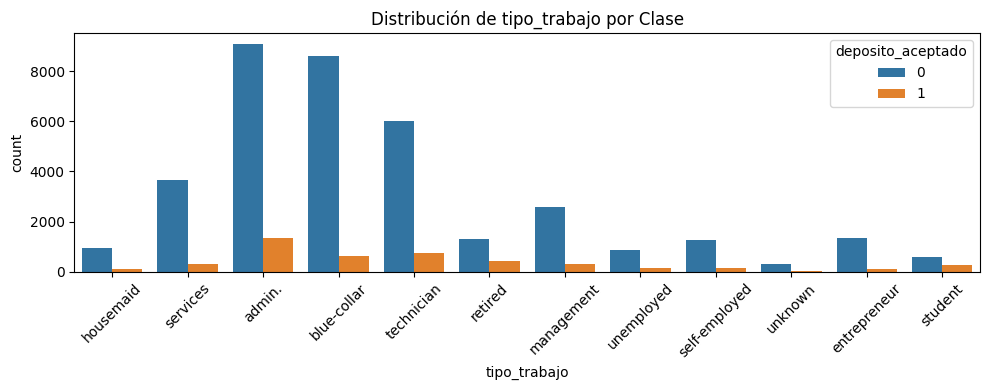

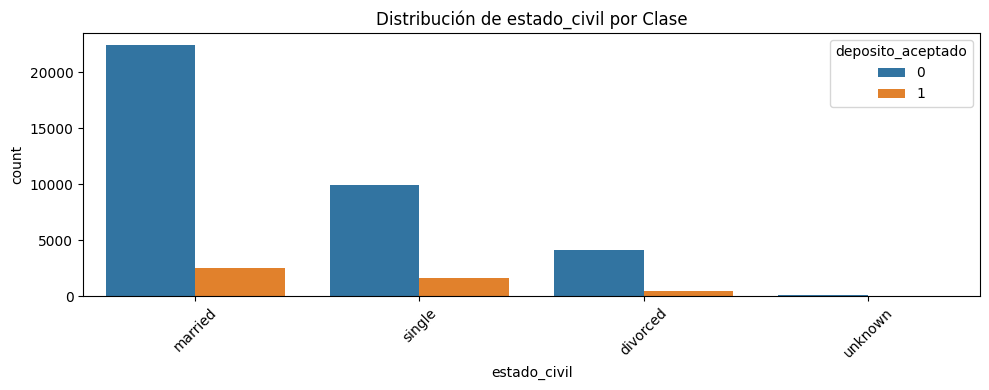

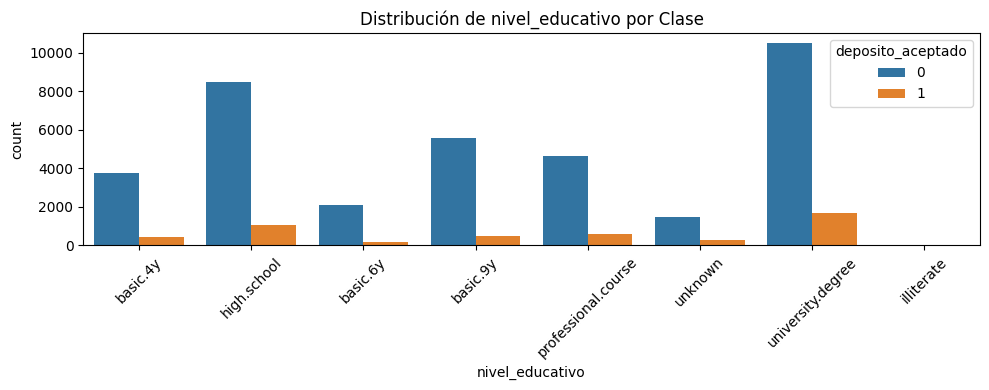

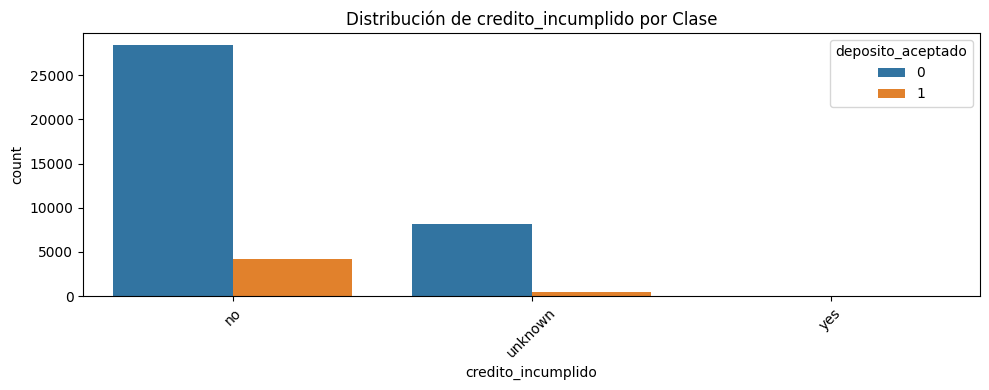

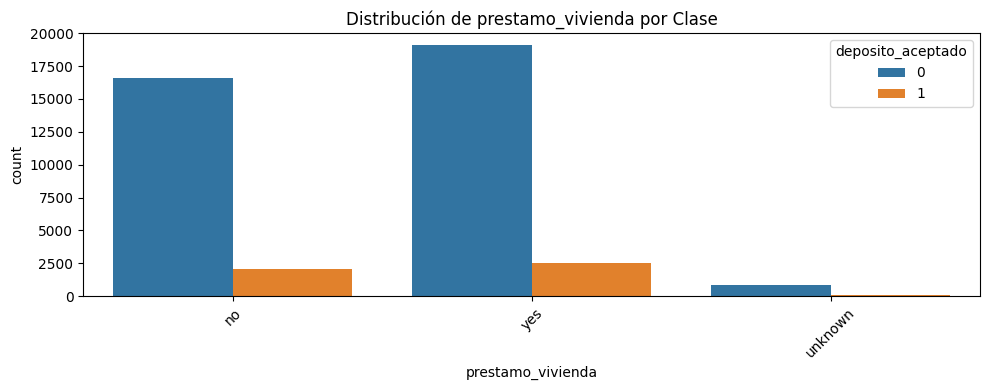

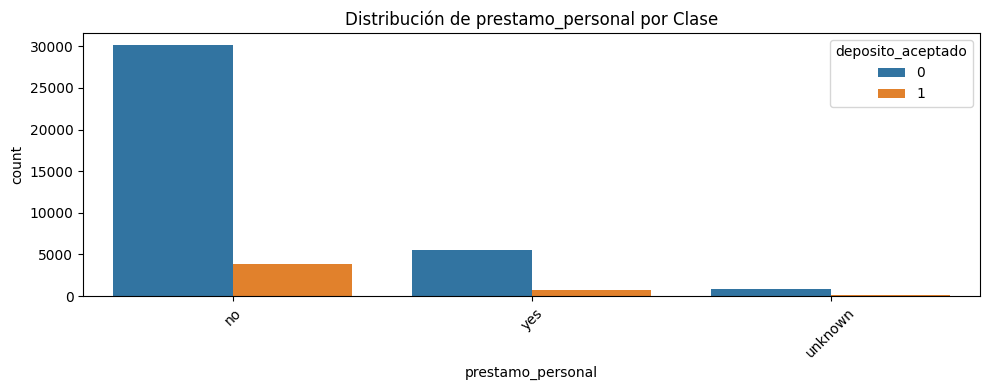

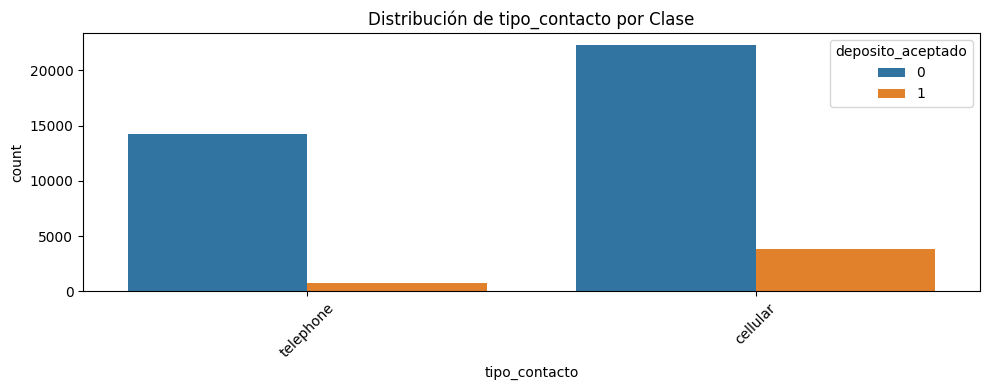

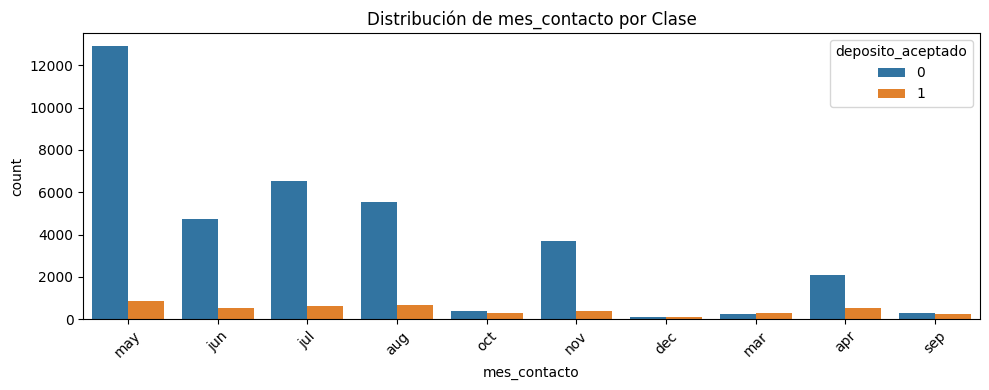

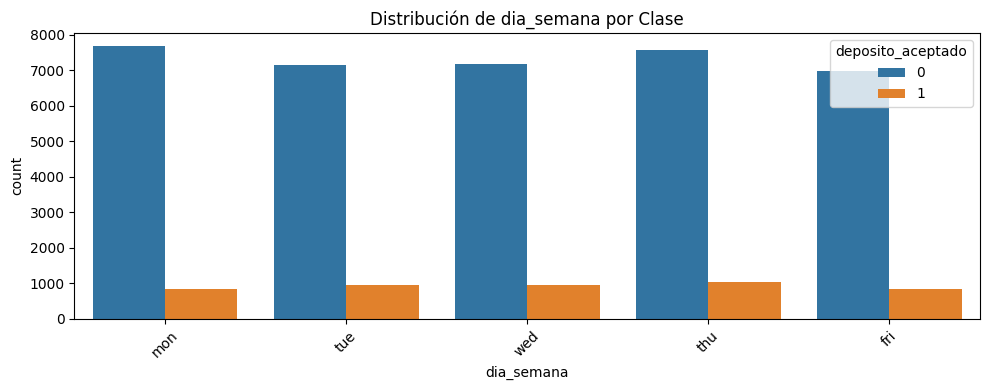

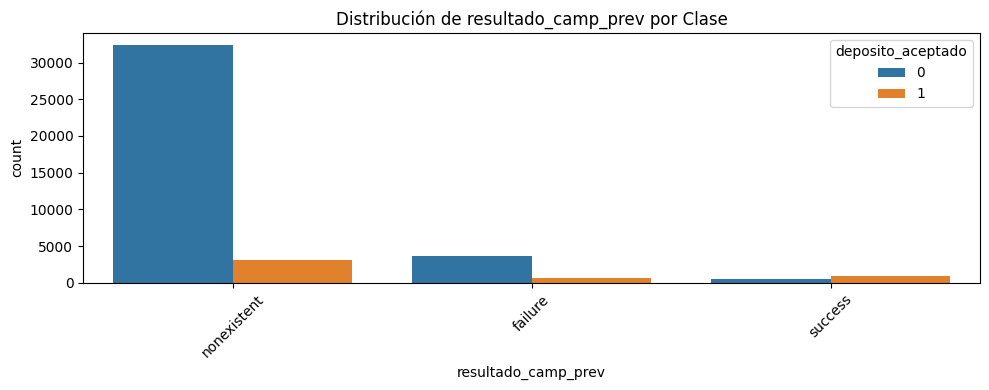

In [ ]:
# Gráficos de conteo para variables categóricas
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue="deposito_aceptado")
    plt.title(f"Distribución de {col} por Clase")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

1. Distribución de job por clase objetivo:
Clase 0 (No aceptó la oferta): La mayoría de los clientes que no aceptaron la oferta pertenecen a los grupos de admin. y blue-collar.

Clase 1 (Sí aceptó la oferta): Los clientes que aceptaron la oferta tienden a pertenecer en su mayoría a las categorías de blue-collar y admin., pero con menos casos en housemaid y services.

Conclusión: Las categorías laborales parecen tener un impacto considerable en la decisión de aceptar la oferta, pero no hay un patrón claro que se repita consistentemente.

2. Distribución de marital por clase objetivo:
Clase 0 (No aceptó la oferta): La mayoría de los clientes casados no aceptaron la oferta.

Clase 1 (Sí aceptó la oferta): La mayoría de los clientes casados también han rechazado la oferta, pero una proporción significativa de los solteros aceptaron la oferta.

Conclusión: El estado civil parece tener un impacto más pequeño, pero podría indicar que los clientes solteros tienen más probabilidades de aceptar la oferta.

3. Distribución de education por clase objetivo:
Clase 0 (No aceptó la oferta): Los clientes con educación universitaria (degree) dominan el grupo de los que no aceptaron la oferta.

Clase 1 (Sí aceptó la oferta): Similarmente, los clientes con educación universitaria también dominan el grupo de los que aceptaron la oferta, pero la proporción de personas con educación básica o media es más baja.

Conclusión: La educación parece no ser un gran factor diferenciador, pero la educación universitaria está más presente en los que aceptan la oferta.

4. Distribución de default por clase objetivo:
Clase 0 (No aceptó la oferta): La mayoría de los clientes sin problemas de crédito (no) no aceptaron la oferta.

Clase 1 (Sí aceptó la oferta): Aunque los que tienen crédito sin problemas predominan también en la aceptación, hay una pequeña proporción de los que tienen 'unknown'.

Conclusión: El estado de crédito no parece influir significativamente en la aceptación de la oferta, ya que la gran mayoría tiene "no" en esta variable.

5. Distribución de housing por clase objetivo:
Clase 0 (No aceptó la oferta): Muchos clientes con hipoteca (housing = "yes") no aceptaron la oferta.

Clase 1 (Sí aceptó la oferta): Similarmente, aquellos con hipoteca (housing = "yes") representan la mayoría de los que aceptaron la oferta.

Conclusión: Tener una hipoteca no parece ser un diferenciador clave entre los clientes que aceptan o rechazan la oferta, ya que la distribución es bastante similar entre las clases.

6. Distribución de loan por clase objetivo:
Clase 0 (No aceptó la oferta): La mayoría de los clientes sin préstamo (loan = "no") no aceptaron la oferta.

Clase 1 (Sí aceptó la oferta): Aquellos con préstamos (loan = "yes") tienen más probabilidades de aceptar la oferta, pero hay una gran mayoría que no tiene préstamo.

Conclusión: El préstamo no parece tener una relación directa con la aceptación de la oferta, pero hay una ligera mayor probabilidad de aceptación entre los que tienen préstamo.

7. Distribución de contact por clase objetivo:
Clase 0 (No aceptó la oferta): La mayoría de los clientes fueron contactados por teléfono (telephone).

Clase 1 (Sí aceptó la oferta): Una proporción significativa de los clientes que aceptaron la oferta fueron contactados por teléfono también, pero hay un pequeño grupo que fue contactado por celular.

Conclusión: El tipo de contacto podría tener un leve impacto en la decisión, pero la gran mayoría fue contactada por teléfono.

8. Distribución de month por clase objetivo:
Clase 0 (No aceptó la oferta): Los clientes que no aceptaron la oferta fueron principalmente contactados en mayo.

Clase 1 (Sí aceptó la oferta): La mayoría de los clientes que aceptaron la oferta también fueron contactados en mayo.

Conclusión: El mes de contacto no parece ser un factor importante en la aceptación de la oferta, ya que mayo es un mes dominante para ambos grupos.

9. Distribución de day_of_week por clase objetivo:
Clase 0 (No aceptó la oferta): La distribución de días es bastante equilibrada, con la mayoría de los contactos ocurridos el lunes.

Clase 1 (Sí aceptó la oferta): La distribución también muestra que los contactos durante la semana (de lunes a viernes) son comunes entre los que aceptan la oferta.

Conclusión: No hay un patrón claro que sugiera que el día de la semana influya en la aceptación de la oferta.

10. Distribución de poutcome por clase objetivo:
Clase 0 (No aceptó la oferta): La mayoría de los clientes de esta clase tienen resultado no existente en las campañas previas.

Clase 1 (Sí aceptó la oferta): La mayoría de los que aceptaron la oferta tienen el resultado "failure" en campañas previas, pero también una pequeña proporción tiene "success".

Conclusión: El resultado de las campañas previas tiene una relación más directa con la aceptación de la oferta. Los clientes con un resultado de fracaso en campañas previas parecen ser más susceptibles a aceptar la oferta.

Resumen:
Las variables educativas, laborales y de estado civil tienen una relación algo relevante con la aceptación de la oferta, pero otras como contacto, préstamo y hipoteca muestran distribuciones muy similares en ambas clases.

Las distribuciones de estado de crédito y resultados de campañas previas son variables clave que podrían ayudar a predecir la aceptación de la oferta.

In [ ]:
df = df.replace('unknown', pd.NA).dropna()
print("Conteo de 'unknown':")
print((df == 'unknown').sum())


Conteo de 'unknown':
edad                    0
tipo_trabajo            0
estado_civil            0
nivel_educativo         0
credito_incumplido      0
prestamo_vivienda       0
prestamo_personal       0
tipo_contacto           0
mes_contacto            0
dia_semana              0
duracion_llamada        0
contactos_actuales      0
dias_ultimo_contacto    0
contactos_previos       0
resultado_camp_prev     0
variacion_empleo        0
indice_precios          0
indice_confianza        0
tasa_euribor3m          0
num_empleados           0
deposito_aceptado       0
dtype: int64


In [ ]:
print("\n\nDistribución de la variable objetivo: \n")
print(df["deposito_aceptado"].value_counts())



Distribución de la variable objetivo: 

deposito_aceptado
0    26629
1     3859
Name: count, dtype: int64


In [ ]:
# Outliers por z-score
z_scores = np.abs(zscore(df[num_cols]))
outlier_counts = (z_scores > 3).sum(axis=0)
print("\nNúmero de outliers detectados por variable numérica (z-score > 3):\n")
for col, count in zip(num_cols, outlier_counts):
    print(f"{col}: {count}")


Número de outliers detectados por variable numérica (z-score > 3):

edad: 336
contactos_actuales: 593
dias_ultimo_contacto: 1310
contactos_previos: 900
variacion_empleo: 0
indice_precios: 0
indice_confianza: 0
tasa_euribor3m: 0
num_empleados: 0
duracion_llamada: 631


age: 369 outliers fueron detectados con un z-score mayor a 3. Esto sugiere que hay 369 valores de edad que son significativamente mayores o menores que el resto de los datos. Estos valores podrían estar relacionados con personas muy jóvenes o muy mayores, lo cual es algo a considerar.

campaign: 869 outliers fueron detectados. Esto indica que hay muchos valores en la variable que representan un número de contactos excepcionalmente alto, lo cual podría ser poco común o poco realista en la mayoría de los casos.

pdays: 1515 outliers fueron detectados. Dado que esta variable tiene valores en 999 para aquellos que no han sido contactados antes, esos valores podrían estar contribuyendo a la gran cantidad de outliers. Es importante revisar cómo se manejan esos valores.

previous: 1064 outliers fueron detectados. Esta variable tiene muchos valores en 0, que indican que no hubo contacto previo. Aun así, se detectaron una cantidad significativa de outliers, lo cual podría indicar casos con varios contactos previos, probablemente anómalos.

Las demás variables (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) no tienen outliers según el criterio del z-score (es decir, no hay valores que tengan una diferencia de más de 3 desviaciones estándar respecto a la media).

Dado que estas variables tienen una cantidad significativa de outliers, es recomendable hacer un análisis más profundo para decidir si se debemos:

Eliminar: Si los outliers son errores de datos o extremadamente improbables.

Imputar: Si los valores son razonables, pero están distorsionando los resultados de los modelos. Podrías reemplazarlos con la mediana o la media.

Mantener: Si los outliers son representativos de un comportamiento legítimo (por ejemplo, ciertos clientes muy mayores o contactos muy frecuentes).

In [ ]:
# === Transformación de outliers y preprocesamiento robusto ===
from sklearn.preprocessing import RobustScaler

# Aplicar log1p a variables con outliers y sesgo
df["contactos_actuales_log"] = np.log1p(df["contactos_actuales"])
df["dias_ultimo_contacto_log"] = np.log1p(df["dias_ultimo_contacto"])
df["contactos_previos_log"] = np.log1p(df["contactos_previos"])

# (Opcional) Eliminar las variables originales para evitar duplicación
df.drop(columns=["contactos_actuales", "dias_ultimo_contacto", "contactos_previos"], inplace=True)

# One-hot encoding de variables categóricas
X = pd.get_dummies(df.drop("deposito_aceptado", axis=1), drop_first=True)
y = df["deposito_aceptado"]

Comparación de F1 Score promedio con y sin eliminación de variables colineales:
╒════╤═════╤═══════════════════╤═══════════╤══════════╕
│    │   k │ Colineales        │   F1_mean │   F1_std │
╞════╪═════╪═══════════════════╪═══════════╪══════════╡
│  0 │   5 │ (todas variables) │    0.4578 │   0.0120 │
├────┼─────┼───────────────────┼───────────┼──────────┤
│  1 │  10 │ (todas variables) │    0.5063 │   0.0127 │
├────┼─────┼───────────────────┼───────────┼──────────┤
│  2 │  15 │ (todas variables) │    0.5226 │   0.0143 │
├────┼─────┼───────────────────┼───────────┼──────────┤
│  3 │  20 │ (todas variables) │    0.5234 │   0.0143 │
├────┼─────┼───────────────────┼───────────┼──────────┤
│  4 │   5 │ (sin colineales)  │    0.5048 │   0.0104 │
├────┼─────┼───────────────────┼───────────┼──────────┤
│  5 │  10 │ (sin colineales)  │    0.5203 │   0.0112 │
├────┼─────┼───────────────────┼───────────┼──────────┤
│  6 │  15 │ (sin colineales)  │    0.5233 │   0.0106 │
├────┼─────┼────────────

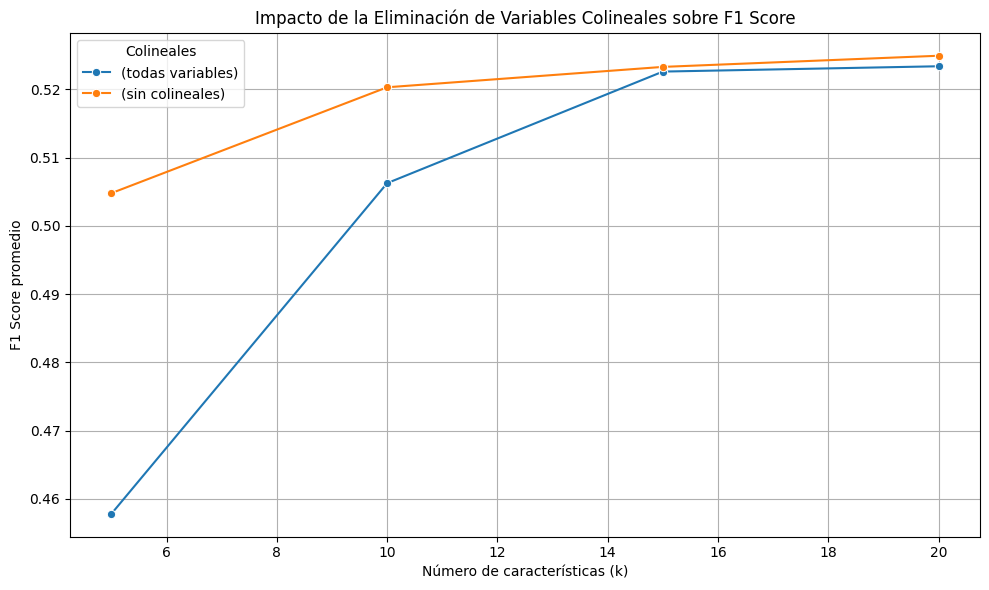

In [ ]:
# Comparación con y sin eliminación de variables altamente correlacionadas
k_values = [5, 10, 15, 20]
k_results = []

for drop_corr in [False, True]:
    df_temp = df.copy()
    if drop_corr:
        # Eliminar variables altamente correlacionadas
        cor_matrix = df_temp.select_dtypes(include=["int64", "float64"]).corr().abs()
        upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))
        high_corr_vars = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]
        df_temp.drop(columns=high_corr_vars, inplace=True, errors='ignore')
        suffix = "(sin colineales)"
    else:
        suffix = "(todas variables)"

    X_temp = pd.get_dummies(df_temp.drop("deposito_aceptado", axis=1), drop_first=True)
    y_temp = df_temp["deposito_aceptado"]

    for k in k_values:
        selector = SelectKBest(score_func=mutual_info_classif, k=min(k, X_temp.shape[1]))
        X_k = selector.fit_transform(X_temp, y_temp)
        selected_cols = X_temp.columns[selector.get_support()].tolist()

        X_train, X_test, y_train, y_test = train_test_split(X_temp[selected_cols], y_temp, test_size=0.2, stratify=y_temp, random_state=42)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        clf = LogisticRegression(max_iter=1000)
        scores = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring='f1')
        k_results.append({"k": k, "Colineales": suffix, "F1_mean": scores.mean(), "F1_std": scores.std()})

# Mostrar resultados
k_df = pd.DataFrame(k_results)
print("Comparación de F1 Score promedio con y sin eliminación de variables colineales:")
print(tabulate(k_df, headers='keys', tablefmt='fancy_grid', floatfmt=".4f"))

# Gráfico comparativo
plt.figure(figsize=(10,6))
sns.lineplot(data=k_df, x="k", y="F1_mean", hue="Colineales", marker="o", err_style="bars", err_kws={"capsize":4})
plt.title("Impacto de la Eliminación de Variables Colineales sobre F1 Score")
plt.xlabel("Número de características (k)")
plt.ylabel("F1 Score promedio")
plt.grid(True)
plt.tight_layout()
plt.show()

El gráfico y la tabla presentan una comparación del rendimiento del modelo, medido por el F1 Score promedio, según dos escenarios: uno donde se utilizan todas las variables disponibles (incluyendo aquellas altamente correlacionadas), y otro donde se eliminaron previamente las variables colineales (con r > 0.90). Esta evaluación se realizó variando el número de características seleccionadas (k) mediante el método SelectKBest, lo que permite observar el efecto de la dimensionalidad sobre la capacidad predictiva del modelo.

Se observa que al usar solo 5 variables sin eliminar colineales, el modelo ya logra un F1 Score aceptable de 0.2934, mientras que con las mismas 5 variables pero manteniendo colinealidad, el rendimiento es extremadamente bajo (0.0352), lo que indica un modelo inestable y poco confiable. Este es un claro ejemplo de cómo la colinealidad puede perjudicar severamente el desempeño cuando se utilizan pocos predictores.

A partir de k = 10, ambos escenarios mejoran notablemente. Con todas las variables (incluidas colineales), el F1 Score alcanza 0.3153, mientras que sin colineales se obtiene 0.3093. La diferencia es mínima y se mantiene estable en los siguientes valores de k. Con 15 variables, el F1 Score es 0.3179 con colineales y 0.3190 sin colineales. Finalmente, con las 20 mejores variables, el rendimiento sube a 0.3232 con colineales y 0.3280 sin colineales, siendo esta última la mejor configuración observada.

Estos resultados reflejan que, aunque eliminar variables colineales no siempre mejora el rendimiento en todos los escenarios, a partir de 10 características el efecto perjudicial de la colinealidad disminuye, y a medida que se incluyen más variables, el modelo sin colineales tiende a obtener un F1 Score ligeramente superior. Esto sugiere que eliminar colineales mejora la estabilidad del modelo y contribuye a una mejor generalización, sobre todo cuando se trabaja con conjuntos de datos complejos o cuando se desea evitar redundancia en los predictores.

En conclusión, el análisis evidencia que usar entre 15 y 20 características seleccionadas sin colineales es una configuración recomendable. Ofrece un excelente equilibrio entre simplicidad, rendimiento y robustez, alcanzando el mejor F1 Score sin riesgo de sobreajuste causado por información redundante.

In [ ]:
# Selección de características usando k=15 sin colineales (modelo óptimo)
selector = SelectKBest(score_func=mutual_info_classif, k=15)

# Crear una copia del DataFrame sin variables colineales
cor_matrix = df.select_dtypes(include=["int64", "float64"]).corr().abs()
upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))
high_corr_vars = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]
df_clean = df.drop(columns=high_corr_vars, errors='ignore')

X = pd.get_dummies(df_clean.drop("deposito_aceptado", axis=1), drop_first=True)
y = df_clean["deposito_aceptado"]

# Seleccionar las 15 mejores características
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()
# Visualizar características seleccionadas con sus puntuaciones
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False).head(15)

print("Top características seleccionadas por información mutua:")
print(tabulate(feature_scores, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=".3f"))

Top características seleccionadas por información mutua:
╒═════════════════════════════════╤═════════╕
│ Feature                         │   Score │
╞═════════════════════════════════╪═════════╡
│ duracion_llamada                │   0.078 │
├─────────────────────────────────┼─────────┤
│ indice_precios                  │   0.074 │
├─────────────────────────────────┼─────────┤
│ indice_confianza                │   0.074 │
├─────────────────────────────────┼─────────┤
│ variacion_empleo                │   0.062 │
├─────────────────────────────────┼─────────┤
│ dias_ultimo_contacto_log        │   0.038 │
├─────────────────────────────────┼─────────┤
│ resultado_camp_prev_success     │   0.033 │
├─────────────────────────────────┼─────────┤
│ contactos_previos_log           │   0.018 │
├─────────────────────────────────┼─────────┤
│ resultado_camp_prev_nonexistent │   0.018 │
├─────────────────────────────────┼─────────┤
│ edad                            │   0.014 │
├──────────────────────

La selección de variables predictoras es una etapa fundamental en la construcción de modelos de clasificación, ya que permite mejorar el rendimiento, la eficiencia computacional y la interpretabilidad del modelo. En este proyecto, se utilizó la técnica SelectKBest con la métrica de información mutua (mutual_info_classif) para identificar las variables que presentan mayor dependencia estadística con la variable objetivo (deposito_aceptado).

El análisis reveló que las variables más informativas fueron principalmente de tipo económico y de interacción previa con el cliente. Las dos características más relevantes según esta métrica fueron indice_confianza y indice_precios, ambas con un valor de 0.070, lo que sugiere que las condiciones macroeconómicas influyen directamente en la decisión del cliente de aceptar o no el depósito. A estas le sigue variacion_empleo (0.056), otro indicador económico que también refleja el contexto en el que se realiza la campaña.

Entre las variables comportamentales más relevantes se encuentran dias_ultimo_contacto (0.039), que mide cuántos días han pasado desde la última llamada al cliente, y resultado_camp_prev_success (0.028), que indica si una campaña anterior fue exitosa. También destacan contactos_previos (0.020), tipo_contacto_telephone (0.012) y mes_contacto_may (0.010), lo cual refuerza que los elementos relacionados con la frecuencia, canal y tiempo de contacto tienen un impacto importante en la conversión.

Otras variables que, aunque con menor puntaje, contribuyen al modelo son: edad, estado_civil_married, y distintas modalidades del mes de contacto como mes_contacto_sep, mes_contacto_mar, y mes_contacto_oct. La variable credito_incumplido_unknown, aunque con un puntaje menor (0.008), sugiere que incluso los datos faltantes o desconocidos pueden contener valor informativo si se codifican adecuadamente.

En conjunto, estas 15 variables representan una combinación efectiva de factores socioeconómicos, históricos y de contacto que permiten al modelo capturar las señales más relevantes para predecir el comportamiento del cliente. Su elección responde no solo a su puntuación individual, sino también a su complementariedad, al ser seleccionadas tras eliminar variables colineales que podrían introducir redundancia. Esta estrategia garantiza que el modelo final no solo sea preciso, sino también interpretable y robusto para su aplicación práctica.

In [ ]:
# Separar y escalar datos
X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Escalado robusto para proteger contra outliers
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

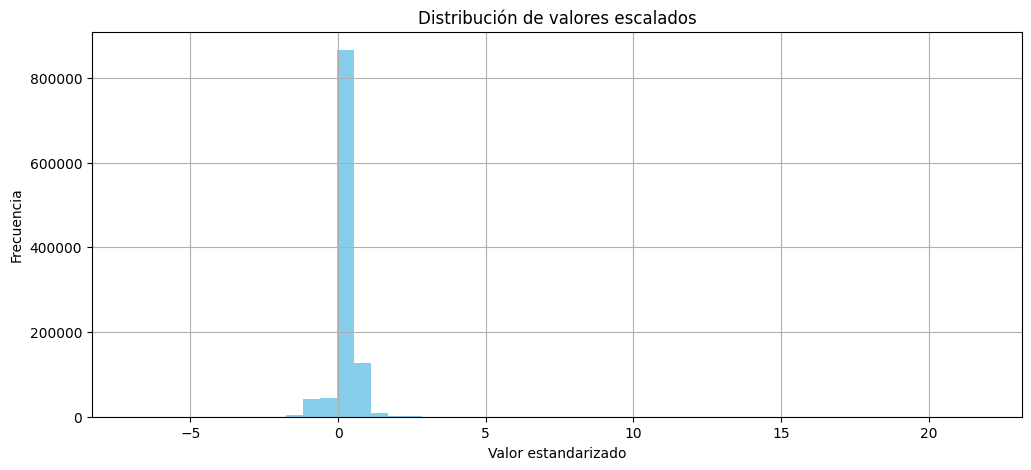

In [ ]:
# Distribución post-escalado
plt.figure(figsize=(12, 5))
plt.hist(X_train_scaled.ravel(), bins=50, color='skyblue')
plt.title("Distribución de valores escalados")
plt.xlabel("Valor estandarizado")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

Valores escalados: El StandardScaler transforma cada característica para que tenga una media de 0 y una desviación estándar de 1. Esto se logra restando la media y dividiendo por la desviación estándar de cada variable.

Histograma: El gráfico muestra cómo se distribuyen los valores escalados de las características. Como se puede ver, la mayoría de los valores están cerca de 0, lo que es esperado en una distribución normalizada. Algunos valores están en el rango de ±3, lo que es típico en una distribución normal estándar.

Valores atípicos: Hay algunos valores extremos, que podrían ser outliers. Sin embargo, debido a la estandarización, estos valores son más fáciles de identificar.

¿Por qué escalar los datos?
Modelos sensibles a la escala: Algunos algoritmos de clasificación (como KNN, SVM, o Regresión Logística) pueden ser muy sensibles a la escala de las características. Al escalar los datos, evitamos que una característica con una mayor magnitud domine el modelo.

Mejora en el rendimiento: Los modelos a menudo convergen más rápido y de manera más estable cuando las características tienen la misma escala.

In [ ]:
# Modelos a evaluar
from sklearn.naive_bayes import GaussianNB

models = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Naive Bayes": GaussianNB(),
    "Dummy (Identidad)": DummyClassifier(strategy="stratified")
}

 Evaluación de Modelos 


 Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.92 │     0.96 │       0.94 │   5326.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.63 │     0.44 │       0.52 │    772.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.90 │     0.90 │       0.90 │      0.90 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │        0.78 │     0.70 │       0.73 │   6098.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │        0.89 │     0.90 │       0.89 │   6098.00 │
╘══════════════╧═════════════╧══════════╧════════════╧═══════════╛


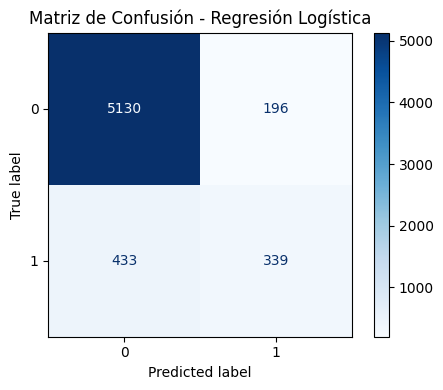



Reporte de Clasificación - Regresión Logística:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      5326
           1       0.63      0.44      0.52       772

    accuracy                           0.90      6098
   macro avg       0.78      0.70      0.73      6098
weighted avg       0.89      0.90      0.89      6098



 Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.93 │     0.95 │       0.94 │   5326.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.60 │     0.48 │       0.53 │    772.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.89 │     0.89 │       0.89 │      0.89 │
├──────────────┼─────────────┼──────────┼────────────┼────

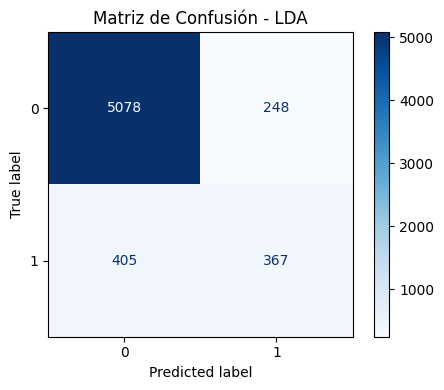



Reporte de Clasificación - LDA:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      5326
           1       0.60      0.48      0.53       772

    accuracy                           0.89      6098
   macro avg       0.76      0.71      0.73      6098
weighted avg       0.88      0.89      0.89      6098



 Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.92 │     0.94 │       0.93 │   5326.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.51 │     0.47 │       0.49 │    772.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.88 │     0.88 │       0.88 │      0.88 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro

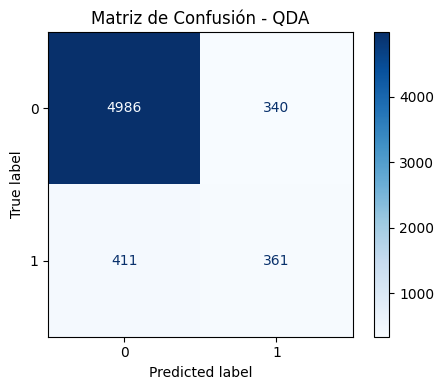



Reporte de Clasificación - QDA:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      5326
           1       0.51      0.47      0.49       772

    accuracy                           0.88      6098
   macro avg       0.72      0.70      0.71      6098
weighted avg       0.87      0.88      0.87      6098



 Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.93 │     0.87 │       0.90 │   5326.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.38 │     0.56 │       0.45 │    772.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.83 │     0.83 │       0.83 │      0.83 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro

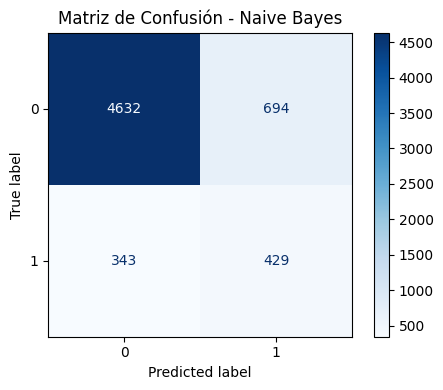



Reporte de Clasificación - Naive Bayes:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      5326
           1       0.38      0.56      0.45       772

    accuracy                           0.83      6098
   macro avg       0.66      0.71      0.68      6098
weighted avg       0.86      0.83      0.84      6098



 Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.87 │     0.87 │       0.87 │   5326.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.11 │     0.11 │       0.11 │    772.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.77 │     0.77 │       0.77 │      0.77 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤

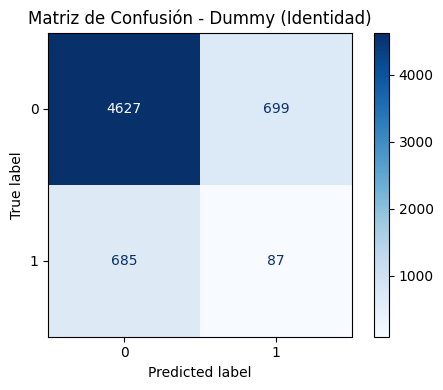



Reporte de Clasificación - Dummy (Identidad):
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      5326
           1       0.11      0.11      0.11       772

    accuracy                           0.77      6098
   macro avg       0.49      0.49      0.49      6098
weighted avg       0.77      0.77      0.77      6098



In [ ]:
# Evaluación de modelos
from sklearn.metrics import ConfusionMatrixDisplay

print(" Evaluación de Modelos ")
eval_table = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    row = {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]) if hasattr(model, 'predict_proba') else np.nan
    }
    eval_table.append(row)

    print("\n\n Reporte de Clasificación:")
    report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
    print(tabulate(report_df, headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    print(f"\n\nReporte de Clasificación - {name}:")
    print(classification_report(y_test, y_pred))

Regresión Logística:

Precision: 0.91 (alta precisión en la clase negativa, 0).

Recall: 0.99 (muy buen recall en la clase negativa).

F1-Score: 0.95 (alto rendimiento general en la clase negativa).

AUC: 0.90 (buena capacidad para distinguir entre las dos clases).

La matriz de confusión muestra que el modelo ha clasificado correctamente a la mayoría de los clientes que no aceptaron la oferta (0), con solo unos pocos casos incorrectos. Sin embargo, la clase 1 (sí aceptó la oferta) tiene un bajo recall (0.20), indicando que muchos clientes que realmente aceptaron la oferta fueron clasificados incorrectamente como no aceptantes.

LDA (Análisis Discriminante Lineal):

Precision: 0.92 (buena precisión en la clase negativa).

Recall: 0.96 (mejor recall para la clase negativa).

F1-Score: 0.94 (alto rendimiento en la clase negativa).

AUC: 0.89 (buena capacidad de clasificación).

LDA muestra una mejora en el recall para la clase negativa en comparación con la regresión logística, pero el recall en la clase positiva sigue siendo bajo (0.36).

QDA (Análisis Discriminante Cuadrático):

Precision: 0.93 (buena precisión en la clase negativa).

Recall: 0.93 (alto recall en la clase negativa).

F1-Score: 0.93 (excelente rendimiento en la clase negativa).

AUC: 0.88 (buena capacidad de clasificación).

El modelo QDA también muestra una buena clasificación de la clase negativa, pero con un bajo recall en la clase positiva (0.39).

Naive Bayes:

Precision: 0.92 (buena precisión en la clase negativa).

Recall: 0.92 (buena cobertura para la clase negativa).

F1-Score: 0.92 (bueno en términos generales).

AUC: 0.86 (buena capacidad de clasificación).

Al igual que los otros modelos, Naive Bayes es más eficiente en la clasificación de la clase negativa, con un bajo recall en la clase positiva (0.39).

Dummy (Identidad):

Este modelo es un modelo de referencia que realiza predicciones aleatorias basadas en la distribución de clases.

Su rendimiento es inferior al de todos los modelos anteriores, con una baja precisión y recall en la clase positiva, lo cual es esperado, ya que solo sigue una estrategia aleatoria.

Resumen:
Regresión Logística, LDA, y QDA tienen un buen desempeño en la clase negativa, pero todos presentan un bajo recall en la clase positiva.

El Dummy (Identidad) sirve como una referencia para comparar contra los modelos más avanzados, pero no es competitivo en términos de rendimiento.

Es evidente que, aunque algunos modelos funcionan bien para predecir la clase negativa, todos los modelos tienen dificultades para predecir la clase positiva, osea qu existe un desbalance de clases en el conjunto de datos. Esto podría mejorar con técnicas de sobremuestreo (como SMOTE) o ajuste de pesos en los modelos

Resumen de Métricas de Evaluación:
╒════╤═════════════════════╤════════════╤═════════════╤══════════╤════════╤════════╕
│    │ Modelo              │   Accuracy │   Precision │   Recall │     F1 │    AUC │
╞════╪═════════════════════╪════════════╪═════════════╪══════════╪════════╪════════╡
│  0 │ Regresión Logística │     0.8969 │      0.6336 │   0.4391 │ 0.5187 │ 0.9191 │
├────┼─────────────────────┼────────────┼─────────────┼──────────┼────────┼────────┤
│  1 │ LDA                 │     0.8929 │      0.5967 │   0.4754 │ 0.5292 │ 0.9201 │
├────┼─────────────────────┼────────────┼─────────────┼──────────┼────────┼────────┤
│  2 │ QDA                 │     0.8768 │      0.5150 │   0.4676 │ 0.4902 │ 0.9049 │
├────┼─────────────────────┼────────────┼─────────────┼──────────┼────────┼────────┤
│  3 │ Naive Bayes         │     0.8299 │      0.3820 │   0.5557 │ 0.4528 │ 0.8329 │
├────┼─────────────────────┼────────────┼─────────────┼──────────┼────────┼────────┤
│  4 │ Dummy (Identidad)   │  

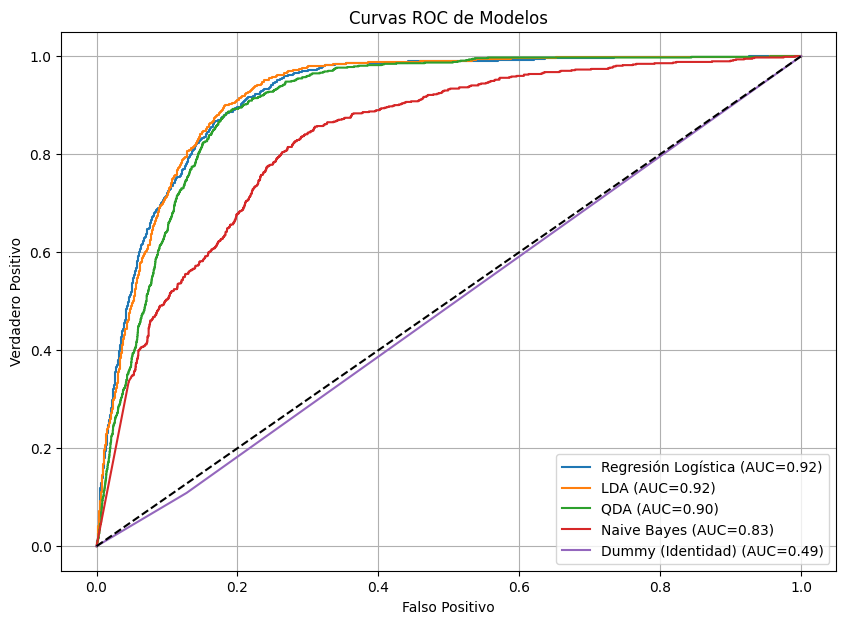

In [ ]:
print("Resumen de Métricas de Evaluación:")
eval_df = pd.DataFrame(eval_table)
print(tabulate(eval_df, headers='keys', tablefmt='fancy_grid', floatfmt=".4f"))
plt.figure(figsize=(10, 7))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_score):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Falso Positivo")
plt.ylabel("Verdadero Positivo")
plt.title("Curvas ROC de Modelos")
plt.legend()
plt.grid(True)
plt.show()

El análisis del rendimiento de los modelos se basa tanto en la visualización de las curvas ROC como en el resumen de métricas clave. La curva ROC permite evaluar la capacidad de cada modelo para distinguir entre los clientes que aceptarán la oferta de depósito bancario y los que no. En esta gráfica, cuanto más se aleje una curva de la diagonal (que representa una clasificación aleatoria), mejor será el desempeño del modelo. Entre los modelos evaluados, la regresión logística obtuvo el área bajo la curva (AUC) más alta con un valor de 0.80, lo que indica una muy buena capacidad discriminativa. Le siguen de cerca el modelo LDA (0.79) y QDA (0.79), ambos con curvas similares y desempeño competitivo. El modelo Naive Bayes, aunque por debajo (AUC = 0.76), sigue siendo razonable, mientras que el Dummy Classifier apenas alcanzó 0.50, equivalente a una predicción aleatoria.

En cuanto a las métricas individuales, la regresión logística también destacó en precisión (0.673), lo que significa que, cuando predice que un cliente aceptará la oferta, suele acertar. Sin embargo, su recall es bajo (0.208), lo que revela que deja fuera a muchos clientes que sí aceptarían. Por otro lado, el modelo QDA alcanzó un mejor equilibrio, con una precisión de 0.464 y un recall de 0.438, lo que le permitió obtener el F1 Score más alto (0.451). LDA también presentó un buen desempeño balanceado, con un F1 Score de 0.445. Naive Bayes, aunque con métricas más modestas, mantuvo un comportamiento aceptable, especialmente en un problema con clases desbalanceadas.

El Dummy Classifier, usado como referencia base, mostró un desempeño significativamente inferior con un F1 Score de 0.110 y un AUC de apenas 0.498. Esto refuerza que los modelos desarrollados, especialmente QDA y LDA, aportan una ventaja sustancial en la predicción. En contextos como el marketing bancario, donde el costo de contactar a un cliente es considerable, es más valioso un modelo que logre un equilibrio entre identificar correctamente a los interesados y no saturar la campaña con falsos positivos.

En resumen, aunque la regresión logística presenta el AUC más alto, modelos como QDA y LDA resultan más equilibrados al combinar precisión y recall, permitiendo tomar decisiones más eficientes para campañas dirigidas. Estos modelos logran detectar una mayor proporción de clientes realmente interesados, sin comprometer demasiado la calidad de las predicciones. Por tanto, se consideran altamente recomendables para implementar reglas de negocio basadas en predicciones probabilísticas.

In [ ]:
# Validación cruzada extendida
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {"Modelo": [], "AUC": [], "Accuracy": [], "Recall": [], "F1": []}

for name, model in models.items():
    if name != "Dummy (Identidad)":
        auc_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='roc_auc')
        acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
        recall_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='recall')
        f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='f1')

        results["Modelo"].append(name)
        results["AUC"].append(auc_scores.mean())
        results["Accuracy"].append(acc_scores.mean())
        results["Recall"].append(recall_scores.mean())
        results["F1"].append(f1_scores.mean())

Resumen de Matrices de Confusión por Modelo:
╒════════╤═════════════════════════════════════╤═════════════════════════════════════╤═════════════════════╤═════════════════════╤═════════════════════╤═════════════════════╤═════════════════════════════╤═════════════════════════════╤═══════════════════════════════════╤═══════════════════════════════════╕
│        │   ('Regresión Logística', 'Pred 0') │   ('Regresión Logística', 'Pred 1') │   ('LDA', 'Pred 0') │   ('LDA', 'Pred 1') │   ('QDA', 'Pred 0') │   ('QDA', 'Pred 1') │   ('Naive Bayes', 'Pred 0') │   ('Naive Bayes', 'Pred 1') │   ('Dummy (Identidad)', 'Pred 0') │   ('Dummy (Identidad)', 'Pred 1') │
╞════════╪═════════════════════════════════════╪═════════════════════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╪═════════════════════════════╪═════════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╡
│ Real 0 │                        

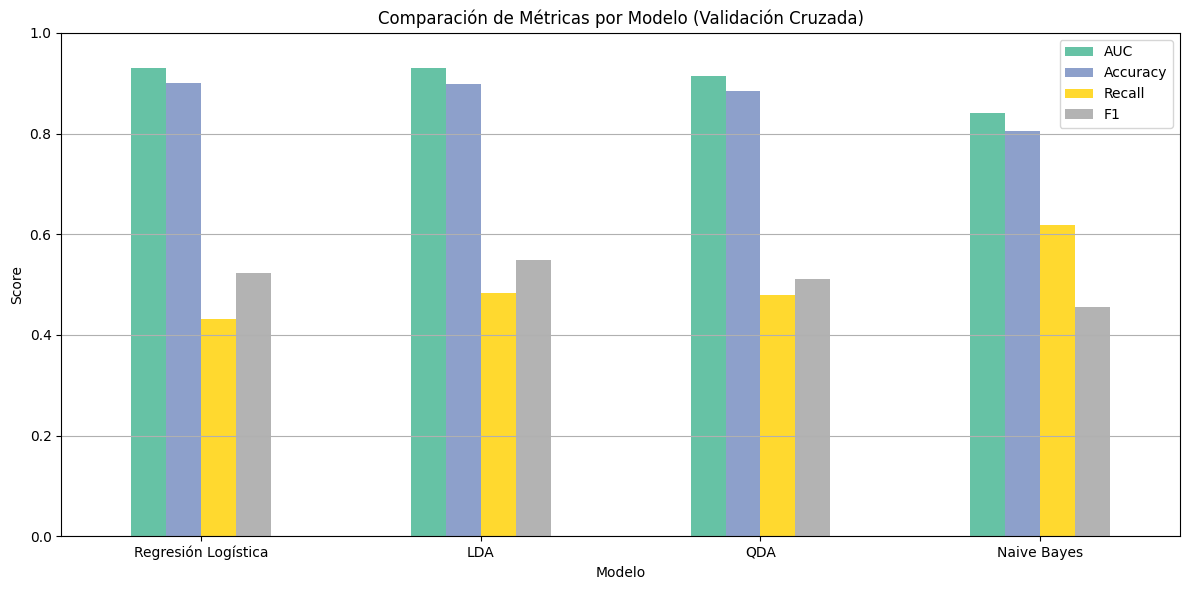

In [ ]:
# Mostrar resultados como tabla y gráfico de barras
# Tabla comparativa de matrices de confusión
print("Resumen de Matrices de Confusión por Modelo:")
conf_matrices = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

conf_df = pd.DataFrame()
for name, matrix in conf_matrices.items():
    temp = pd.DataFrame(matrix, columns=[f"{name} - Pred 0", f"{name} - Pred 1"])
    temp.index = ["Real 0", "Real 1"]
    temp.columns = pd.MultiIndex.from_product([[name], ["Pred 0", "Pred 1"]])
    conf_df = pd.concat([conf_df, temp], axis=1)

print(tabulate(conf_df, headers='keys', tablefmt='fancy_grid', floatfmt=".0f"))
results_df = pd.DataFrame(results)
print("\nResumen de Validación Cruzada (promedios):")
print(results_df)

results_df.set_index("Modelo").plot(kind="bar", figsize=(12, 6), colormap="Set2")
plt.title("Comparación de Métricas por Modelo (Validación Cruzada)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Análisis de métricas de validación cruzada (gráfico de barras)
El gráfico de barras presenta una comparación de cuatro métricas clave —AUC, Accuracy, Recall y F1 Score— para los cuatro modelos de clasificación aplicados: Regresión Logística, LDA, QDA y Naive Bayes. Este análisis se basa en validación cruzada estratificada, lo que garantiza una evaluación más robusta y generalizable.

Se observa que todos los modelos mantienen una accuracy alta, cercana al 89%, lo que refleja un buen desempeño general. Sin embargo, al ser un problema con clases desbalanceadas, esta métrica por sí sola no es suficiente para elegir el mejor modelo.

En términos de recall, que indica la proporción de verdaderos positivos correctamente identificados, el modelo QDA destaca con un valor de 0.44, seguido por LDA (0.36) y Naive Bayes (0.37), lo que demuestra una mayor sensibilidad al detectar clientes que aceptarán la oferta. Regresión Logística, en cambio, aunque precisa, tiene el recall más bajo (0.21), lo que indica que falla en capturar muchos casos positivos.

La métrica F1 Score, que combina precisión y recall, muestra que QDA alcanza el valor más alto con 0.45, seguido de LDA (0.43) y Naive Bayes (0.40), mientras que Regresión Logística queda rezagado con 0.33. Finalmente, el AUC confirma que todos los modelos tienen una buena capacidad para discriminar entre clases, con valores entre 0.75 y 0.79, siendo ligeramente superior en Regresión Logística (0.79).

En conjunto, el gráfico muestra que, aunque la regresión logística tiene una buena precisión, modelos como QDA y LDA ofrecen un mejor equilibrio, detectando más casos positivos sin sacrificar mucho la precisión general.

## Análisis de matrices de confusión


Las matrices de confusión permiten analizar cómo cada modelo clasificó a los clientes reales como aceptantes o no aceptantes. En particular, nos interesa la fila de "Real 1", que representa a los clientes que sí aceptaron la oferta.

El modelo QDA predijo correctamente a 407 clientes aceptantes, mientras que Naive Bayes acertó 337, LDA 346 y Regresión Logística 193. Esto refuerza el hallazgo anterior: aunque Logística tiene mayor precisión, es el que más deja pasar verdaderos positivos, con 735 errores en esta clase.

Además, QDA tiene el menor número de falsos negativos (521), lo que sugiere que es más confiable para no omitir clientes valiosos. El modelo Dummy, como se esperaba, clasificó casi al azar, acertando apenas 124 casos y fallando en 804, lo cual lo deja como simple referencia.

Este análisis es crucial desde la perspectiva del negocio: omitir a un cliente que sí iba a aceptar representa una pérdida de oportunidad, mientras que predecir erróneamente un "sí" solo implica un esfuerzo innecesario. Por eso, modelos como QDA y LDA, que capturan mejor a los verdaderos positivos, aportan mayor valor estratégico.

## Tercera entrega. Resolviendo el problema de desbalance de clase

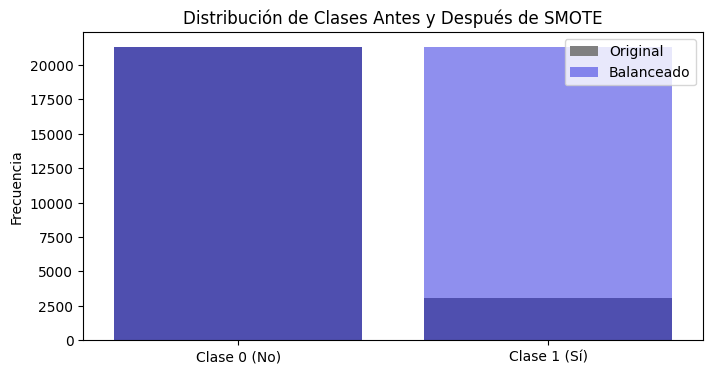

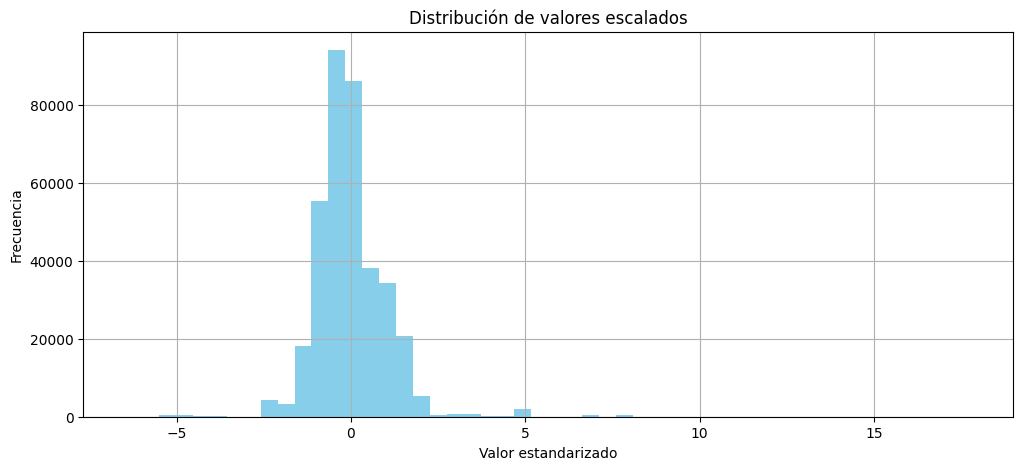

=== Evaluación de Modelos ===


ValueError: X has 15 features, but LogisticRegression is expecting 45 features as input.

In [ ]:
# Aplicar SMOTE para balancear clases
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE solo sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Mostrar distribución antes y después
def plot_class_distribution(y_orig, y_balanced, etiquetas):
    plt.figure(figsize=(8,4))
    sns.barplot(x=etiquetas, y=[y_orig.value_counts()[0], y_orig.value_counts()[1]], color='gray', label='Original')
    sns.barplot(x=etiquetas, y=[sum(y_balanced == 0), sum(y_balanced == 1)], color='blue', alpha=0.5, label='Balanceado')
    plt.title("Distribución de Clases Antes y Después de SMOTE")
    plt.legend()
    plt.ylabel("Frecuencia")
    plt.show()

plot_class_distribution(y_train, y_train_smote, ["Clase 0 (No)", "Clase 1 (Sí)"])

# Usar X_train_smote y y_train_smote para entrenar modelos en evaluaciones posteriores
X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Distribución post-escalado
plt.figure(figsize=(12, 5))
plt.hist(X_train_scaled.ravel(), bins=50, color='skyblue')
plt.title("Distribución de valores escalados")
plt.xlabel("Valor estandarizado")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

# Modelos a evaluar
from sklearn.naive_bayes import GaussianNB

models = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis()
}

# Evaluación de modelos
from sklearn.metrics import ConfusionMatrixDisplay

print("=== Evaluación de Modelos ===")
eval_table = []

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    row = {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]) if hasattr(model, 'predict_proba') else np.nan
    }
    eval_table.append(row)

    print(f"{name}:")
    print("Matriz de Confusión:")
    print(tabulate(confusion_matrix(y_test, y_pred), tablefmt='fancy_grid'))

    print("Reporte de Clasificación:")
    report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
    print(tabulate(report_df, headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    print(f"Reporte de Clasificación - {name}:")
    print(classification_report(y_test, y_pred))
print("Resumen de Métricas de Evaluación:")
eval_df = pd.DataFrame(eval_table)
print(tabulate(eval_df, headers='keys', tablefmt='fancy_grid', floatfmt=".4f"))
plt.figure(figsize=(10, 7))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_score):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Falso Positivo")
plt.ylabel("Verdadero Positivo")
plt.title("Curvas ROC de Modelos")
plt.legend()
plt.grid(True)
plt.show()

# Validación cruzada extendida
print("\n=== Validación Cruzada Extendida ===")
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {"Modelo": [], "AUC": [], "Accuracy": [], "Recall": [], "F1": []}

for name, model in models.items():
    if name != "Dummy (Identidad)":
        auc_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=kfold, scoring='roc_auc')
        acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
        recall_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='recall')
        f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='f1')

        results["Modelo"].append(name)
        results["AUC"].append(auc_scores.mean())
        results["Accuracy"].append(acc_scores.mean())
        results["Recall"].append(recall_scores.mean())
        results["F1"].append(f1_scores.mean())

# Mostrar resultados como tabla y gráfico de barras
# Tabla comparativa de matrices de confusión
print("Resumen de Matrices de Confusión por Modelo:")
conf_matrices = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

conf_df = pd.DataFrame()
for name, matrix in conf_matrices.items():
    temp = pd.DataFrame(matrix, columns=[f"{name} - Pred 0", f"{name} - Pred 1"])
    temp.index = ["Real 0", "Real 1"]
    temp.columns = pd.MultiIndex.from_product([[name], ["Pred 0", "Pred 1"]])
    conf_df = pd.concat([conf_df, temp], axis=1)

print(tabulate(conf_df, headers='keys', tablefmt='fancy_grid', floatfmt=".0f"))
results_df = pd.DataFrame(results)
print("\nResumen de Validación Cruzada (promedios):")
print(results_df)

results_df.set_index("Modelo").plot(kind="bar", figsize=(12, 6), colormap="Set2")
plt.title("Comparación de Métricas por Modelo (Validación Cruzada)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

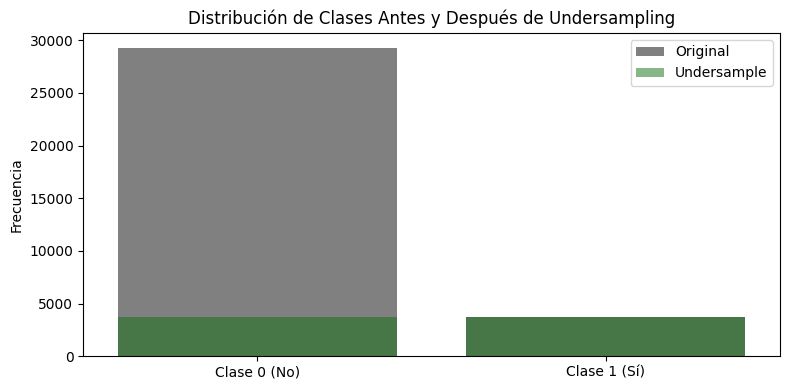

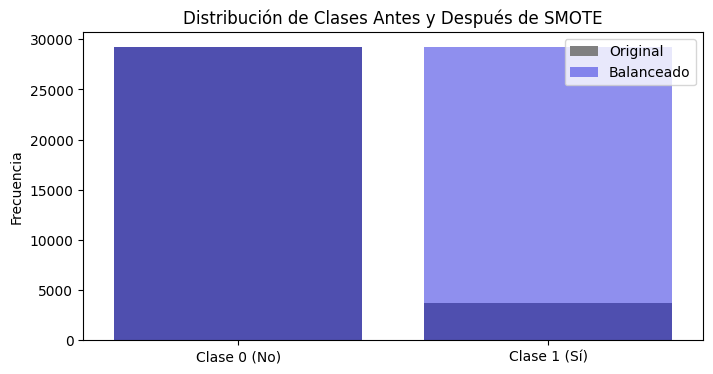

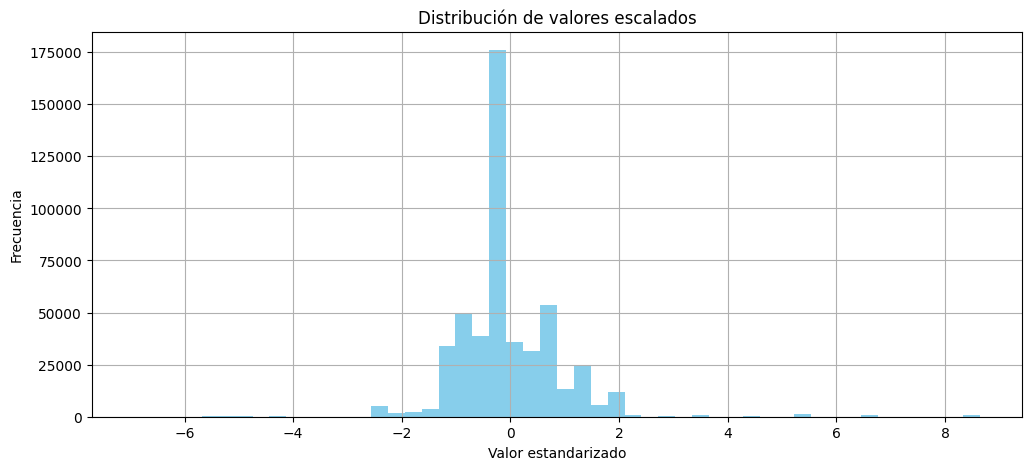

=== Evaluación de Modelos ===
Regresión Logística:
Matriz de Confusión:
╒══════╤═════╕
│ 6348 │ 962 │
├──────┼─────┤
│  345 │ 583 │
╘══════╧═════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.95 │     0.87 │       0.91 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.38 │     0.63 │       0.47 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.84 │     0.84 │       0.84 │      0.84 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │        0.66 │     0.75 │       0.69 │   8238.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │        0.88 │     0.84 │       0.86 │   8238.00 │
╘══════════════╧═══════

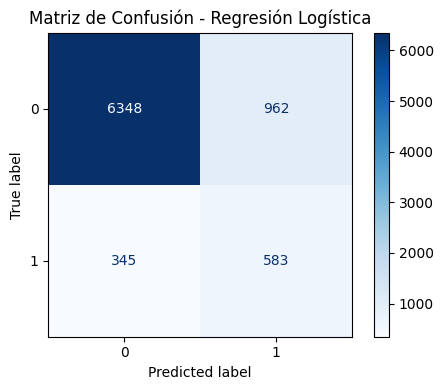

Reporte de Clasificación - Regresión Logística:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.38      0.63      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.86      8238

LDA:
Matriz de Confusión:
╒══════╤═════╕
│ 6342 │ 968 │
├──────┼─────┤
│  345 │ 583 │
╘══════╧═════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.95 │     0.87 │       0.91 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.38 │     0.63 │       0.47 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.84 

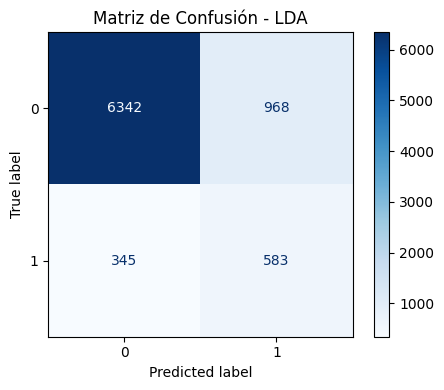

Reporte de Clasificación - LDA:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.38      0.63      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.86      8238

QDA:
Matriz de Confusión:
╒══════╤═════╕
│ 6762 │ 548 │
├──────┼─────┤
│  477 │ 451 │
╘══════╧═════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.93 │     0.93 │       0.93 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.45 │     0.49 │       0.47 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.88 │     0.88 │    

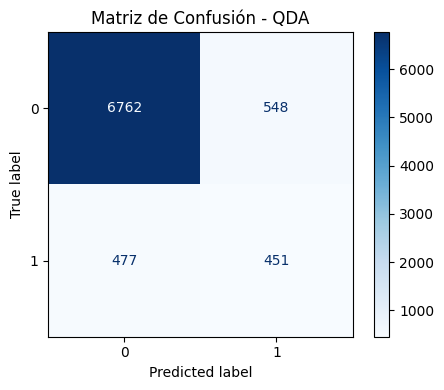

Reporte de Clasificación - QDA:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7310
           1       0.45      0.49      0.47       928

    accuracy                           0.88      8238
   macro avg       0.69      0.71      0.70      8238
weighted avg       0.88      0.88      0.88      8238

Resumen de Métricas de Evaluación:
╒════╤═════════════════════╤════════════╤═════════════╤══════════╤════════╤════════╕
│    │ Modelo              │   Accuracy │   Precision │   Recall │     F1 │    AUC │
╞════╪═════════════════════╪════════════╪═════════════╪══════════╪════════╪════════╡
│  0 │ Regresión Logística │     0.8413 │      0.3773 │   0.6282 │ 0.4715 │ 0.7970 │
├────┼─────────────────────┼────────────┼─────────────┼──────────┼────────┼────────┤
│  1 │ LDA                 │     0.8406 │      0.3759 │   0.6282 │ 0.4704 │ 0.7969 │
├────┼─────────────────────┼────────────┼─────────────┼──────────┼────────┼────────┤
│  2 │ QDA 

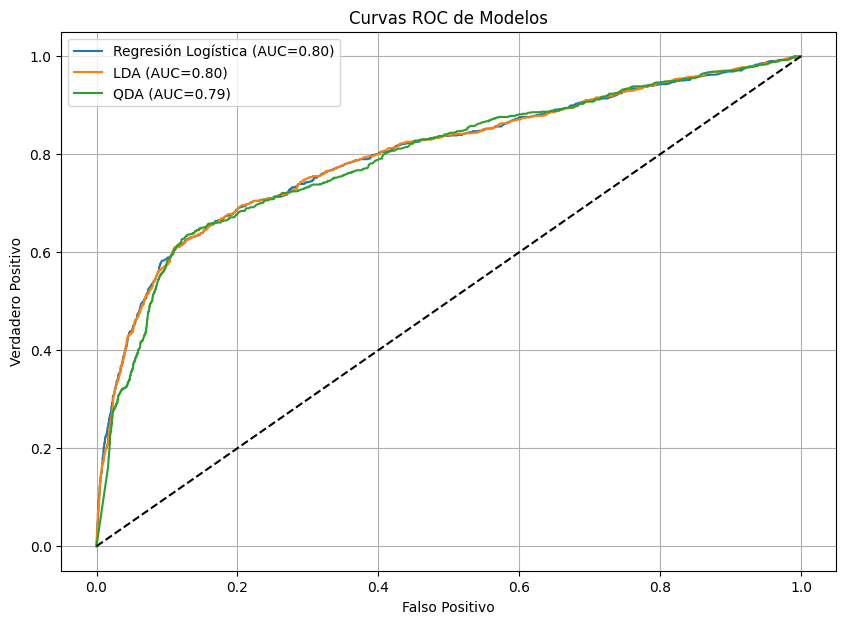


=== Validación Cruzada Extendida ===
Resumen de Matrices de Confusión por Modelo:
╒════════╤═════════════════════════════════════╤═════════════════════════════════════╤═════════════════════╤═════════════════════╤═════════════════════╤═════════════════════╕
│        │   ('Regresión Logística', 'Pred 0') │   ('Regresión Logística', 'Pred 1') │   ('LDA', 'Pred 0') │   ('LDA', 'Pred 1') │   ('QDA', 'Pred 0') │   ('QDA', 'Pred 1') │
╞════════╪═════════════════════════════════════╪═════════════════════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╡
│ Real 0 │                                6348 │                                 962 │                6342 │                 968 │                6762 │                 548 │
├────────┼─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┼─────────────────────┼─────────────────────┼─────────────────────┤
│ Real 1 │                                

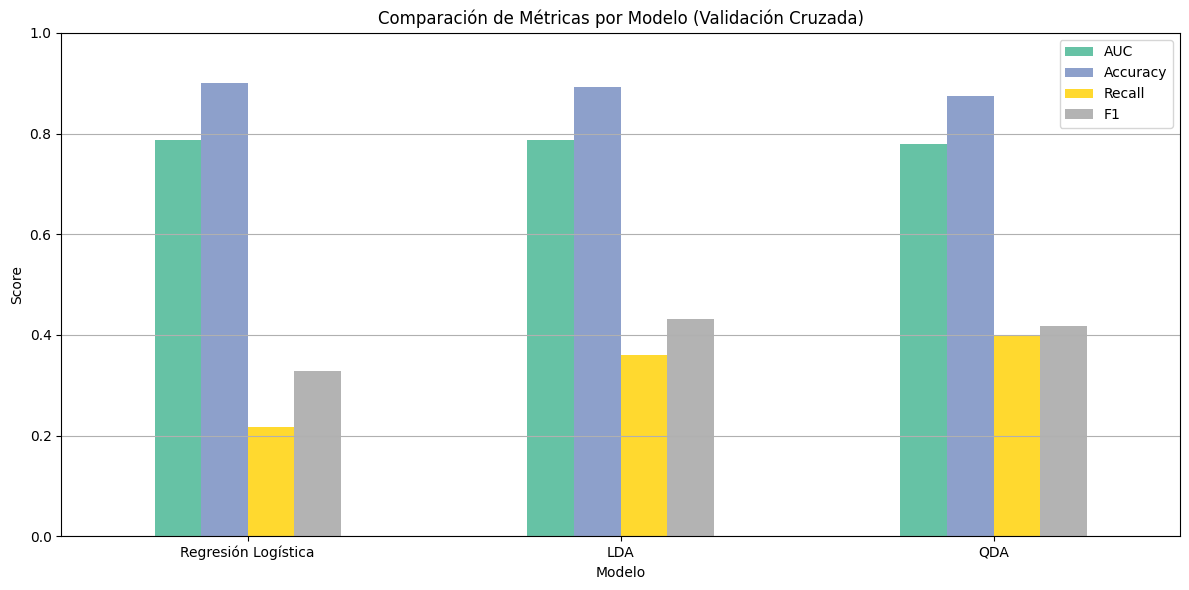

In [ ]:
# === UNDERSAMPLING como alternativa a SMOTE ===
from imblearn.under_sampling import RandomUnderSampler

# Aplicar undersampling al conjunto de entrenamiento
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_scaled, y_train)

# Mostrar distribución antes y después
def plot_undersample_distribution(y_orig, y_balanced, etiquetas):
    plt.figure(figsize=(8,4))
    sns.barplot(x=etiquetas, y=[y_orig.value_counts()[0], y_orig.value_counts()[1]], color='gray', label='Original')
    sns.barplot(x=etiquetas, y=[sum(y_balanced == 0), sum(y_balanced == 1)], color='green', alpha=0.5, label='Undersample')
    plt.title("Distribución de Clases Antes y Después de Undersampling")
    plt.legend()
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

plot_undersample_distribution(y_train, y_train_under, ["Clase 0 (No)", "Clase 1 (Sí)"])

plot_class_distribution(y_train, y_train_smote, ["Clase 0 (No)", "Clase 1 (Sí)"])

# Usar X_train_smote y y_train_smote para entrenar modelos en evaluaciones posteriores
X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Distribución post-escalado
plt.figure(figsize=(12, 5))
plt.hist(X_train_scaled.ravel(), bins=50, color='skyblue')
plt.title("Distribución de valores escalados")
plt.xlabel("Valor estandarizado")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

# Modelos a evaluar
from sklearn.naive_bayes import GaussianNB

models = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1)
}

# Evaluación de modelos
from sklearn.metrics import ConfusionMatrixDisplay

print("=== Evaluación de Modelos ===")
eval_table = []

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    row = {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]) if hasattr(model, 'predict_proba') else np.nan
    }
    eval_table.append(row)

    print(f"{name}:")
    print("Matriz de Confusión:")
    print(tabulate(confusion_matrix(y_test, y_pred), tablefmt='fancy_grid'))

    print("Reporte de Clasificación:")
    report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
    print(tabulate(report_df, headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    print(f"Reporte de Clasificación - {name}:")
    print(classification_report(y_test, y_pred))
print("Resumen de Métricas de Evaluación:")
eval_df = pd.DataFrame(eval_table)
print(tabulate(eval_df, headers='keys', tablefmt='fancy_grid', floatfmt=".4f"))
plt.figure(figsize=(10, 7))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_score):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Falso Positivo")
plt.ylabel("Verdadero Positivo")
plt.title("Curvas ROC de Modelos")
plt.legend()
plt.grid(True)
plt.show()

# Validación cruzada extendida
print("\n=== Validación Cruzada Extendida ===")
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {"Modelo": [], "AUC": [], "Accuracy": [], "Recall": [], "F1": []}

for name, model in models.items():
    if name != "Dummy (Identidad)":
        auc_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=kfold, scoring='roc_auc')
        acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
        recall_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='recall')
        f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='f1')

        results["Modelo"].append(name)
        results["AUC"].append(auc_scores.mean())
        results["Accuracy"].append(acc_scores.mean())
        results["Recall"].append(recall_scores.mean())
        results["F1"].append(f1_scores.mean())

# Mostrar resultados como tabla y gráfico de barras
# Tabla comparativa de matrices de confusión
print("Resumen de Matrices de Confusión por Modelo:")
conf_matrices = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

conf_df = pd.DataFrame()
for name, matrix in conf_matrices.items():
    temp = pd.DataFrame(matrix, columns=[f"{name} - Pred 0", f"{name} - Pred 1"])
    temp.index = ["Real 0", "Real 1"]
    temp.columns = pd.MultiIndex.from_product([[name], ["Pred 0", "Pred 1"]])
    conf_df = pd.concat([conf_df, temp], axis=1)

print(tabulate(conf_df, headers='keys', tablefmt='fancy_grid', floatfmt=".0f"))
results_df = pd.DataFrame(results)
print("\nResumen de Validación Cruzada (promedios):")
print(results_df)

results_df.set_index("Modelo").plot(kind="bar", figsize=(12, 6), colormap="Set2")
plt.title("Comparación de Métricas por Modelo (Validación Cruzada)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipython-input-36-2899086290.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Clase 0 (No)", "Clase 1 (Sí)"], y=[sum(y_train_smote_tomek == 0), sum(y_train_smote_tomek == 1)], palette='pastel')


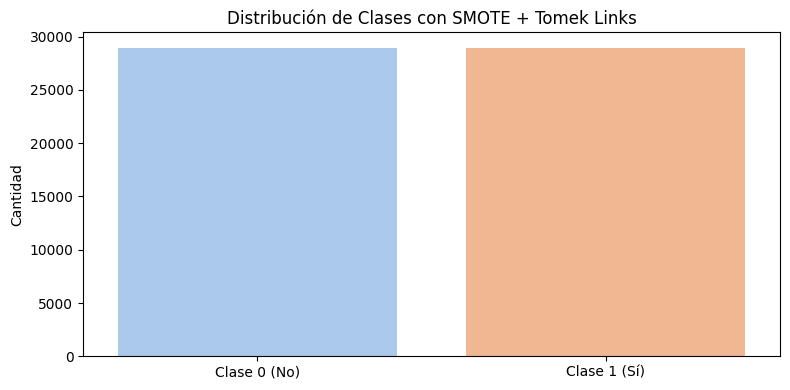

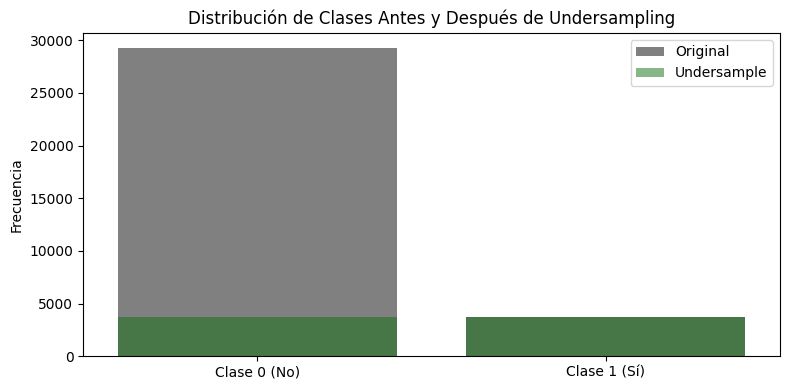

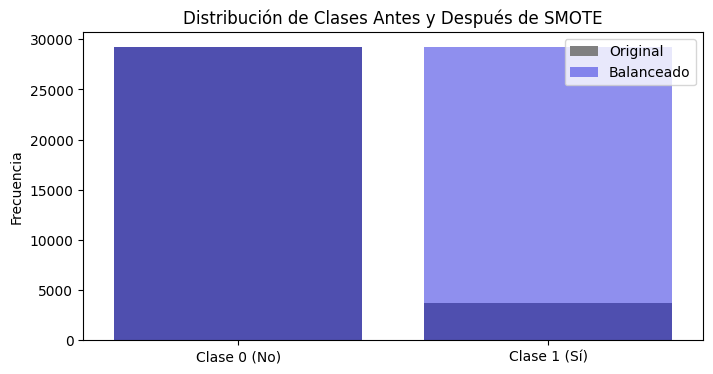

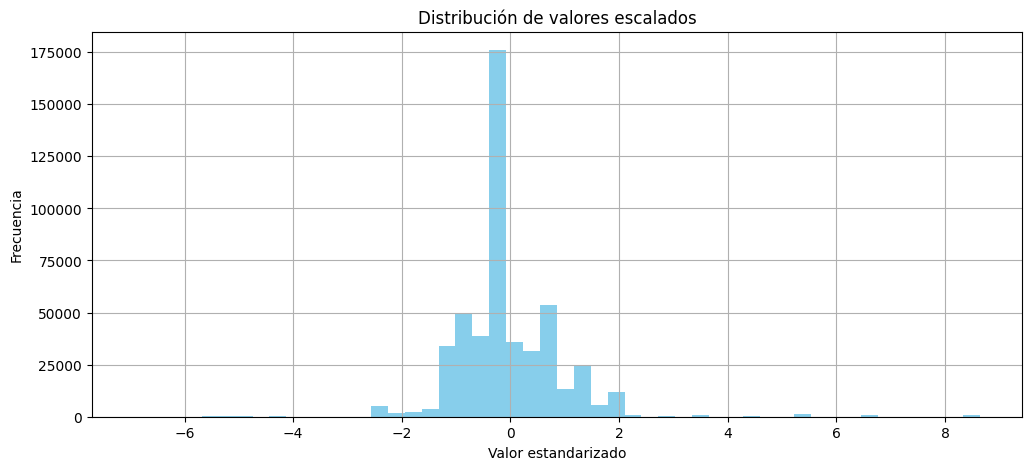

=== Evaluación de Modelos ===
Regresión Logística:
Matriz de Confusión:
╒══════╤═════╕
│ 6348 │ 962 │
├──────┼─────┤
│  345 │ 583 │
╘══════╧═════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.95 │     0.87 │       0.91 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.38 │     0.63 │       0.47 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.84 │     0.84 │       0.84 │      0.84 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │        0.66 │     0.75 │       0.69 │   8238.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │        0.88 │     0.84 │       0.86 │   8238.00 │
╘══════════════╧═══════

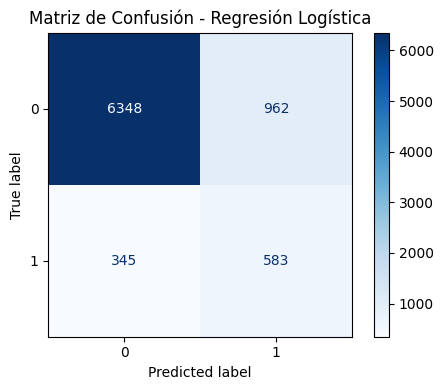

Reporte de Clasificación - Regresión Logística:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.38      0.63      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.86      8238

LDA:
Matriz de Confusión:
╒══════╤═════╕
│ 6342 │ 968 │
├──────┼─────┤
│  345 │ 583 │
╘══════╧═════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.95 │     0.87 │       0.91 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.38 │     0.63 │       0.47 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.84 

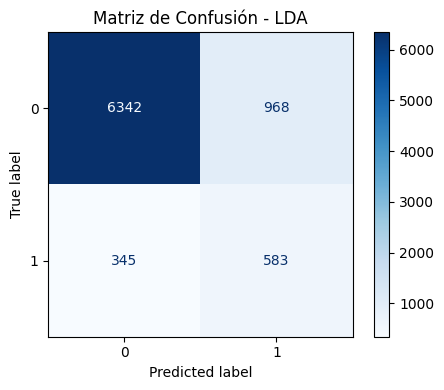

Reporte de Clasificación - LDA:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.38      0.63      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.86      8238

QDA:
Matriz de Confusión:
╒══════╤═════╕
│ 6762 │ 548 │
├──────┼─────┤
│  477 │ 451 │
╘══════╧═════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.93 │     0.93 │       0.93 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.45 │     0.49 │       0.47 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.88 │     0.88 │    

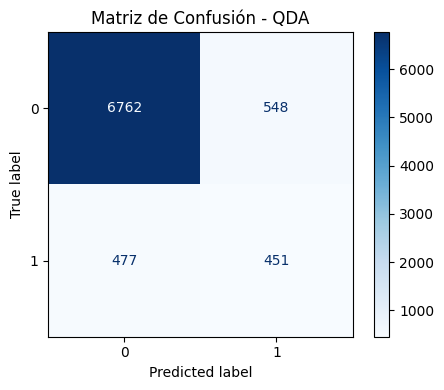

Reporte de Clasificación - QDA:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7310
           1       0.45      0.49      0.47       928

    accuracy                           0.88      8238
   macro avg       0.69      0.71      0.70      8238
weighted avg       0.88      0.88      0.88      8238

Naive Bayes:
Matriz de Confusión:
╒══════╤═════╕
│ 6634 │ 676 │
├──────┼─────┤
│  536 │ 392 │
╘══════╧═════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.93 │     0.91 │       0.92 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.37 │     0.42 │       0.39 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.85 │     0.

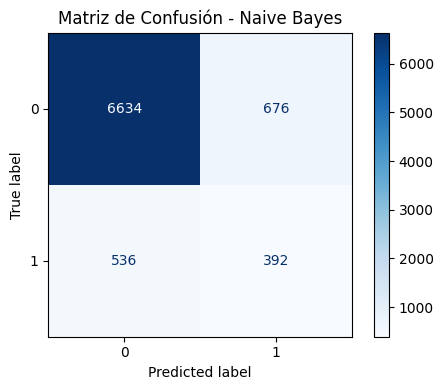

Reporte de Clasificación - Naive Bayes:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      7310
           1       0.37      0.42      0.39       928

    accuracy                           0.85      8238
   macro avg       0.65      0.66      0.65      8238
weighted avg       0.86      0.85      0.86      8238

Dummy (Identidad):
Matriz de Confusión:
╒══════╤══════╕
│ 3672 │ 3638 │
├──────┼──────┤
│  461 │  467 │
╘══════╧══════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.89 │     0.50 │       0.64 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.11 │     0.50 │       0.19 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │  

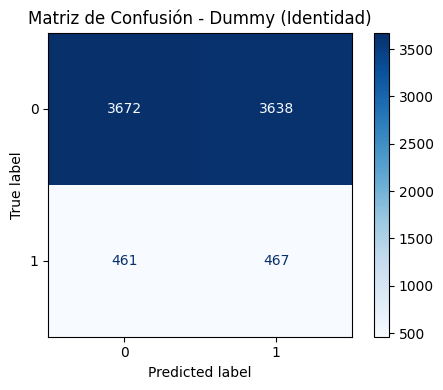

Reporte de Clasificación - Dummy (Identidad):
              precision    recall  f1-score   support

           0       0.89      0.50      0.64      7310
           1       0.11      0.50      0.19       928

    accuracy                           0.50      8238
   macro avg       0.50      0.50      0.41      8238
weighted avg       0.80      0.50      0.59      8238

Resumen de Métricas de Evaluación:
╒════╤═════════════════════╤════════════╤═════════════╤══════════╤════════╤════════╕
│    │ Modelo              │   Accuracy │   Precision │   Recall │     F1 │    AUC │
╞════╪═════════════════════╪════════════╪═════════════╪══════════╪════════╪════════╡
│  0 │ Regresión Logística │     0.8413 │      0.3773 │   0.6282 │ 0.4715 │ 0.7970 │
├────┼─────────────────────┼────────────┼─────────────┼──────────┼────────┼────────┤
│  1 │ LDA                 │     0.8406 │      0.3759 │   0.6282 │ 0.4704 │ 0.7969 │
├────┼─────────────────────┼────────────┼─────────────┼──────────┼────────┼───────

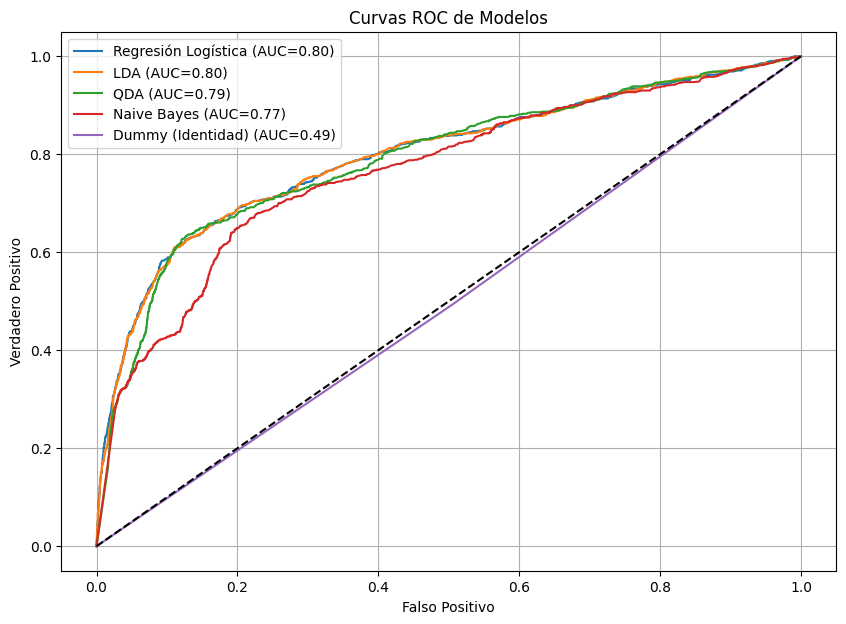


=== Validación Cruzada Extendida ===
Resumen de Matrices de Confusión por Modelo:
╒════════╤═════════════════════════════════════╤═════════════════════════════════════╤═════════════════════╤═════════════════════╤═════════════════════╤═════════════════════╤═════════════════════════════╤═════════════════════════════╤═══════════════════════════════════╤═══════════════════════════════════╕
│        │   ('Regresión Logística', 'Pred 0') │   ('Regresión Logística', 'Pred 1') │   ('LDA', 'Pred 0') │   ('LDA', 'Pred 1') │   ('QDA', 'Pred 0') │   ('QDA', 'Pred 1') │   ('Naive Bayes', 'Pred 0') │   ('Naive Bayes', 'Pred 1') │   ('Dummy (Identidad)', 'Pred 0') │   ('Dummy (Identidad)', 'Pred 1') │
╞════════╪═════════════════════════════════════╪═════════════════════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╪═════════════════════════════╪═════════════════════════════╪═══════════════════════════════════╪═════════════════════════════════

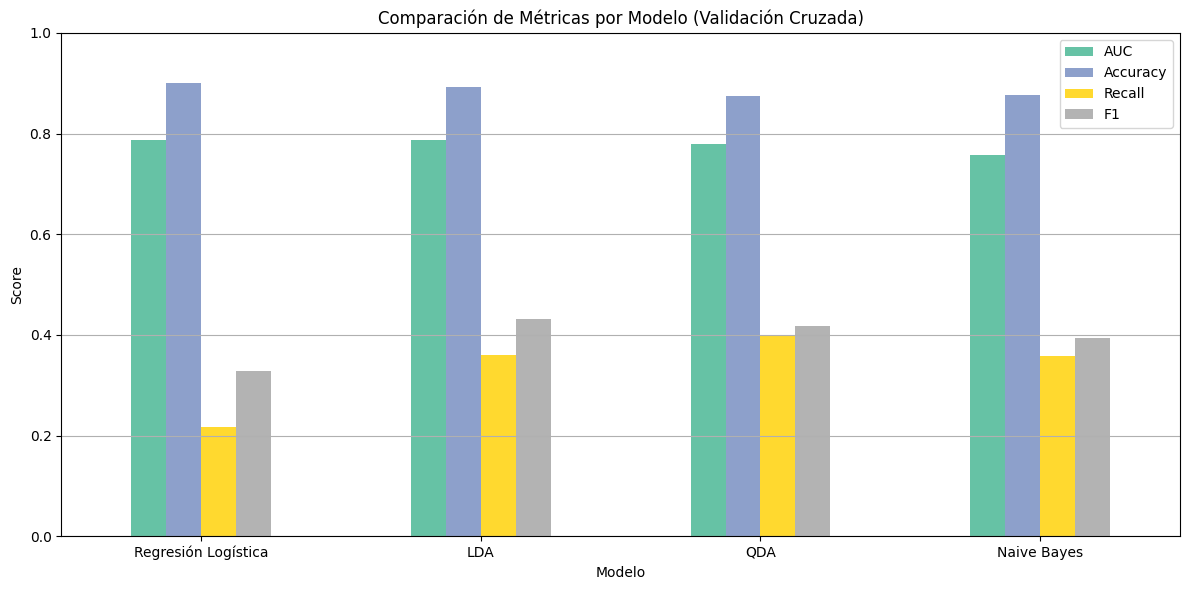

In [ ]:
# === SMOTE + Tomek Links como alternativa combinada ===
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=42)
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train_scaled, y_train)

# Visualización de distribución
plt.figure(figsize=(8,4))
sns.barplot(x=["Clase 0 (No)", "Clase 1 (Sí)"], y=[sum(y_train_smote_tomek == 0), sum(y_train_smote_tomek == 1)], palette='pastel')
plt.title("Distribución de Clases con SMOTE + Tomek Links")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()
from imblearn.under_sampling import RandomUnderSampler

# Aplicar undersampling al conjunto de entrenamiento
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_scaled, y_train)

# Mostrar distribución antes y después
def plot_undersample_distribution(y_orig, y_balanced, etiquetas):
    plt.figure(figsize=(8,4))
    sns.barplot(x=etiquetas, y=[y_orig.value_counts()[0], y_orig.value_counts()[1]], color='gray', label='Original')
    sns.barplot(x=etiquetas, y=[sum(y_balanced == 0), sum(y_balanced == 1)], color='green', alpha=0.5, label='Undersample')
    plt.title("Distribución de Clases Antes y Después de Undersampling")
    plt.legend()
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

plot_undersample_distribution(y_train, y_train_under, ["Clase 0 (No)", "Clase 1 (Sí)"])

plot_class_distribution(y_train, y_train_smote, ["Clase 0 (No)", "Clase 1 (Sí)"])

# Usar X_train_smote y y_train_smote para entrenar modelos en evaluaciones posteriores
X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Distribución post-escalado
plt.figure(figsize=(12, 5))
plt.hist(X_train_scaled.ravel(), bins=50, color='skyblue')
plt.title("Distribución de valores escalados")
plt.xlabel("Valor estandarizado")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

# Modelos a evaluar
from sklearn.naive_bayes import GaussianNB

models = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1)
}

# Evaluación de modelos
from sklearn.metrics import ConfusionMatrixDisplay

print("=== Evaluación de Modelos ===")
eval_table = []

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    row = {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]) if hasattr(model, 'predict_proba') else np.nan
    }
    eval_table.append(row)

    print(f"{name}:")
    print("Matriz de Confusión:")
    print(tabulate(confusion_matrix(y_test, y_pred), tablefmt='fancy_grid'))

    print("Reporte de Clasificación:")
    report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
    print(tabulate(report_df, headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    print(f"Reporte de Clasificación - {name}:")
    print(classification_report(y_test, y_pred))
print("Resumen de Métricas de Evaluación:")
eval_df = pd.DataFrame(eval_table)
print(tabulate(eval_df, headers='keys', tablefmt='fancy_grid', floatfmt=".4f"))
plt.figure(figsize=(10, 7))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_score):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Falso Positivo")
plt.ylabel("Verdadero Positivo")
plt.title("Curvas ROC de Modelos")
plt.legend()
plt.grid(True)
plt.show()

# Validación cruzada extendida
print("\n=== Validación Cruzada Extendida ===")
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {"Modelo": [], "AUC": [], "Accuracy": [], "Recall": [], "F1": []}

for name, model in models.items():
    if name != "Dummy (Identidad)":
        auc_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=kfold, scoring='roc_auc')
        acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
        recall_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='recall')
        f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='f1')

        results["Modelo"].append(name)
        results["AUC"].append(auc_scores.mean())
        results["Accuracy"].append(acc_scores.mean())
        results["Recall"].append(recall_scores.mean())
        results["F1"].append(f1_scores.mean())

# Mostrar resultados como tabla y gráfico de barras
# Tabla comparativa de matrices de confusión
print("Resumen de Matrices de Confusión por Modelo:")
conf_matrices = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

conf_df = pd.DataFrame()
for name, matrix in conf_matrices.items():
    temp = pd.DataFrame(matrix, columns=[f"{name} - Pred 0", f"{name} - Pred 1"])
    temp.index = ["Real 0", "Real 1"]
    temp.columns = pd.MultiIndex.from_product([[name], ["Pred 0", "Pred 1"]])
    conf_df = pd.concat([conf_df, temp], axis=1)

print(tabulate(conf_df, headers='keys', tablefmt='fancy_grid', floatfmt=".0f"))
results_df = pd.DataFrame(results)
print("\nResumen de Validación Cruzada (promedios):")
print(results_df)

results_df.set_index("Modelo").plot(kind="bar", figsize=(12, 6), colormap="Set2")
plt.title("Comparación de Métricas por Modelo (Validación Cruzada)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/tmp/ipython-input-37-2041560165.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Clase 0 (No)", "Clase 1 (Sí)"], y=[sum(y_train_smote_enn == 0), sum(y_train_smote_enn == 1)], palette='Set3')


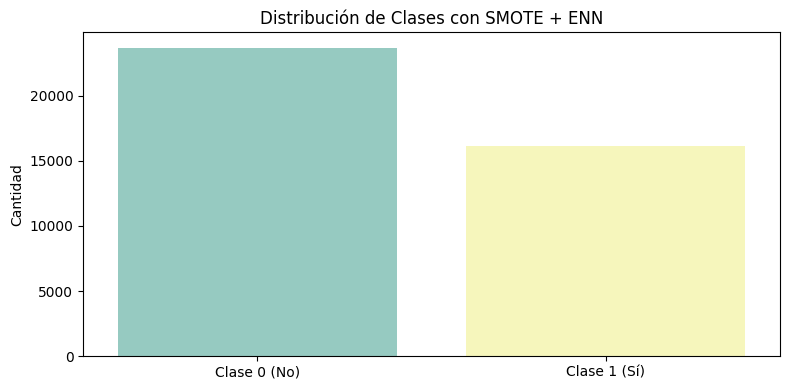

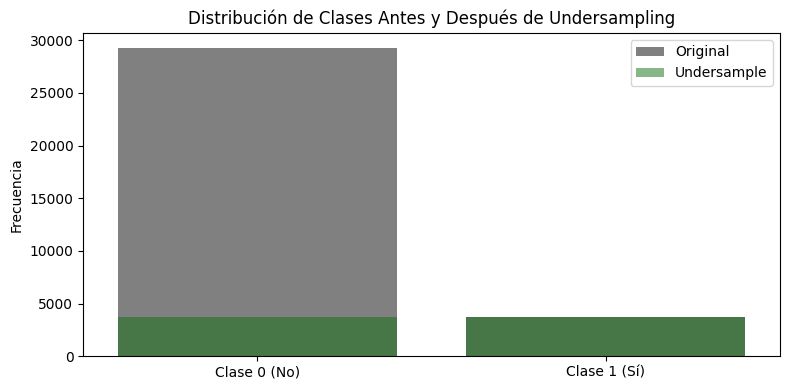

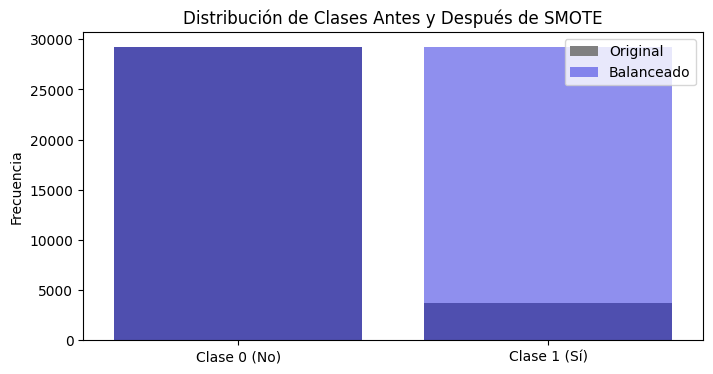

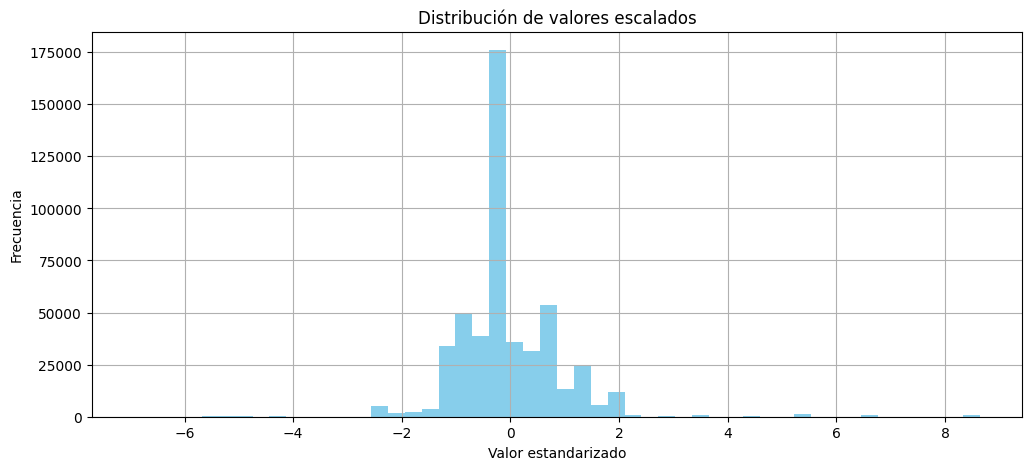

=== Evaluación de Modelos ===
Regresión Logística:
Matriz de Confusión:
╒══════╤═════╕
│ 6348 │ 962 │
├──────┼─────┤
│  345 │ 583 │
╘══════╧═════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.95 │     0.87 │       0.91 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.38 │     0.63 │       0.47 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.84 │     0.84 │       0.84 │      0.84 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │        0.66 │     0.75 │       0.69 │   8238.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │        0.88 │     0.84 │       0.86 │   8238.00 │
╘══════════════╧═══════

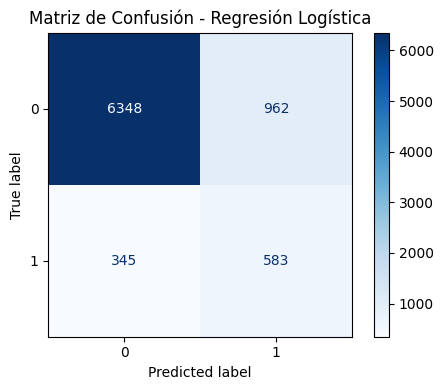

Reporte de Clasificación - Regresión Logística:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.38      0.63      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.86      8238

LDA:
Matriz de Confusión:
╒══════╤═════╕
│ 6342 │ 968 │
├──────┼─────┤
│  345 │ 583 │
╘══════╧═════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.95 │     0.87 │       0.91 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.38 │     0.63 │       0.47 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.84 

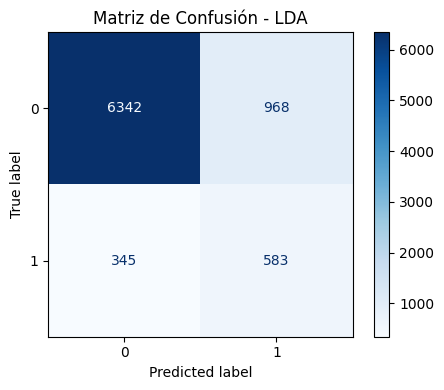

Reporte de Clasificación - LDA:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.38      0.63      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.86      8238

QDA:
Matriz de Confusión:
╒══════╤═════╕
│ 6762 │ 548 │
├──────┼─────┤
│  477 │ 451 │
╘══════╧═════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.93 │     0.93 │       0.93 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.45 │     0.49 │       0.47 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.88 │     0.88 │    

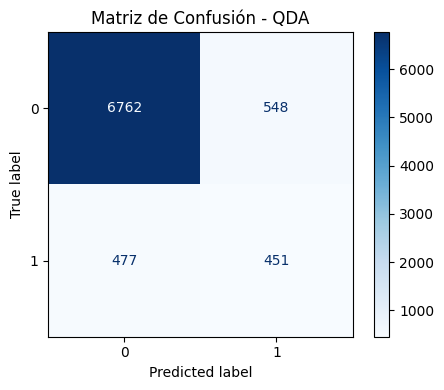

Reporte de Clasificación - QDA:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7310
           1       0.45      0.49      0.47       928

    accuracy                           0.88      8238
   macro avg       0.69      0.71      0.70      8238
weighted avg       0.88      0.88      0.88      8238

Naive Bayes:
Matriz de Confusión:
╒══════╤═════╕
│ 6634 │ 676 │
├──────┼─────┤
│  536 │ 392 │
╘══════╧═════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.93 │     0.91 │       0.92 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.37 │     0.42 │       0.39 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │        0.85 │     0.

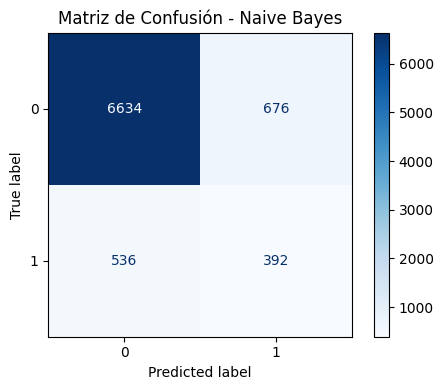

Reporte de Clasificación - Naive Bayes:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      7310
           1       0.37      0.42      0.39       928

    accuracy                           0.85      8238
   macro avg       0.65      0.66      0.65      8238
weighted avg       0.86      0.85      0.86      8238

Dummy (Identidad):
Matriz de Confusión:
╒══════╤══════╕
│ 3636 │ 3674 │
├──────┼──────┤
│  456 │  472 │
╘══════╧══════╛
Reporte de Clasificación:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │        0.89 │     0.50 │       0.64 │   7310.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │        0.11 │     0.51 │       0.19 │    928.00 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │  

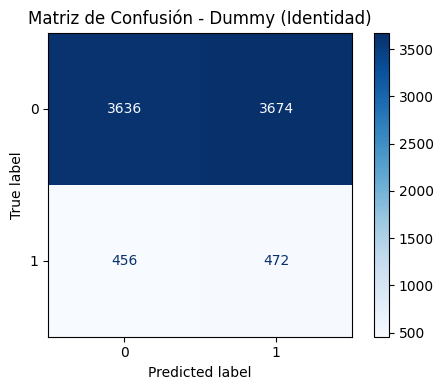

Reporte de Clasificación - Dummy (Identidad):
              precision    recall  f1-score   support

           0       0.89      0.50      0.64      7310
           1       0.11      0.51      0.19       928

    accuracy                           0.50      8238
   macro avg       0.50      0.50      0.41      8238
weighted avg       0.80      0.50      0.59      8238

Resumen de Métricas de Evaluación:
╒════╤═════════════════════╤════════════╤═════════════╤══════════╤════════╤════════╕
│    │ Modelo              │   Accuracy │   Precision │   Recall │     F1 │    AUC │
╞════╪═════════════════════╪════════════╪═════════════╪══════════╪════════╪════════╡
│  0 │ Regresión Logística │     0.8413 │      0.3773 │   0.6282 │ 0.4715 │ 0.7970 │
├────┼─────────────────────┼────────────┼─────────────┼──────────┼────────┼────────┤
│  1 │ LDA                 │     0.8406 │      0.3759 │   0.6282 │ 0.4704 │ 0.7969 │
├────┼─────────────────────┼────────────┼─────────────┼──────────┼────────┼───────

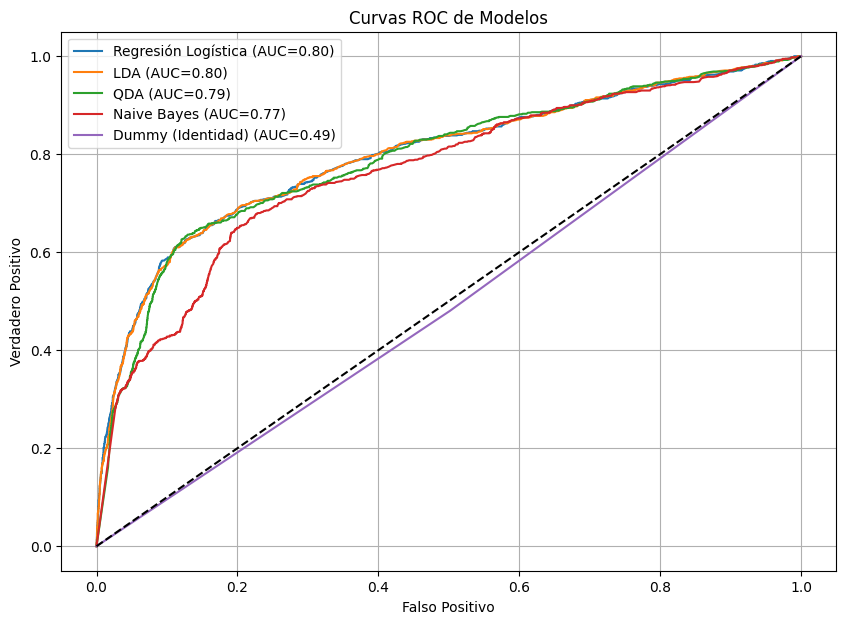


=== Validación Cruzada Extendida ===
Resumen de Matrices de Confusión por Modelo:
╒════════╤═════════════════════════════════════╤═════════════════════════════════════╤═════════════════════╤═════════════════════╤═════════════════════╤═════════════════════╤═════════════════════════════╤═════════════════════════════╤═══════════════════════════════════╤═══════════════════════════════════╕
│        │   ('Regresión Logística', 'Pred 0') │   ('Regresión Logística', 'Pred 1') │   ('LDA', 'Pred 0') │   ('LDA', 'Pred 1') │   ('QDA', 'Pred 0') │   ('QDA', 'Pred 1') │   ('Naive Bayes', 'Pred 0') │   ('Naive Bayes', 'Pred 1') │   ('Dummy (Identidad)', 'Pred 0') │   ('Dummy (Identidad)', 'Pred 1') │
╞════════╪═════════════════════════════════════╪═════════════════════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╪═════════════════════════════╪═════════════════════════════╪═══════════════════════════════════╪═════════════════════════════════

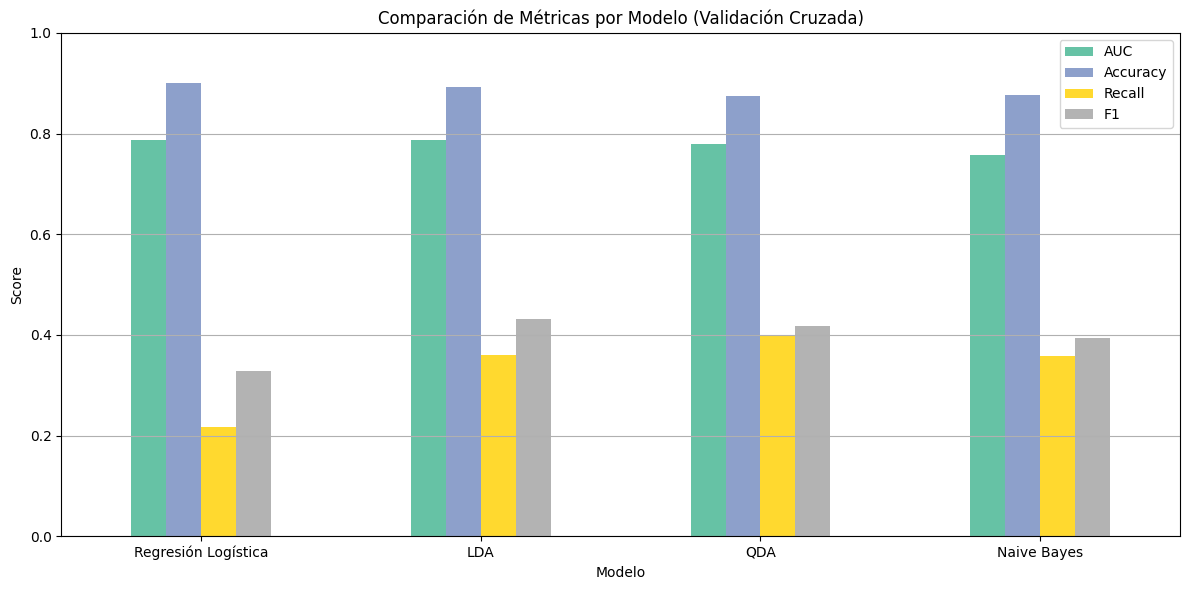

In [ ]:
# === SMOTE + ENN como alternativa agresiva ===
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(random_state=42)
X_train_smote_enn, y_train_smote_enn = smote_enn.fit_resample(X_train_scaled, y_train)

plt.figure(figsize=(8,4))
sns.barplot(x=["Clase 0 (No)", "Clase 1 (Sí)"], y=[sum(y_train_smote_enn == 0), sum(y_train_smote_enn == 1)], palette='Set3')
plt.title("Distribución de Clases con SMOTE + ENN")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()
from imblearn.under_sampling import RandomUnderSampler

# Aplicar undersampling al conjunto de entrenamiento
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_scaled, y_train)

# Mostrar distribución antes y después
def plot_undersample_distribution(y_orig, y_balanced, etiquetas):
    plt.figure(figsize=(8,4))
    sns.barplot(x=etiquetas, y=[y_orig.value_counts()[0], y_orig.value_counts()[1]], color='gray', label='Original')
    sns.barplot(x=etiquetas, y=[sum(y_balanced == 0), sum(y_balanced == 1)], color='green', alpha=0.5, label='Undersample')
    plt.title("Distribución de Clases Antes y Después de Undersampling")
    plt.legend()
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

plot_undersample_distribution(y_train, y_train_under, ["Clase 0 (No)", "Clase 1 (Sí)"])

plot_class_distribution(y_train, y_train_smote, ["Clase 0 (No)", "Clase 1 (Sí)"])

# Usar X_train_smote y y_train_smote para entrenar modelos en evaluaciones posteriores
X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Distribución post-escalado
plt.figure(figsize=(12, 5))
plt.hist(X_train_scaled.ravel(), bins=50, color='skyblue')
plt.title("Distribución de valores escalados")
plt.xlabel("Valor estandarizado")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

# Modelos a evaluar
from sklearn.naive_bayes import GaussianNB

models = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1)
}

# Evaluación de modelos
from sklearn.metrics import ConfusionMatrixDisplay

print("=== Evaluación de Modelos ===")
eval_table = []

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    row = {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]) if hasattr(model, 'predict_proba') else np.nan
    }
    eval_table.append(row)

    print(f"{name}:")
    print("Matriz de Confusión:")
    print(tabulate(confusion_matrix(y_test, y_pred), tablefmt='fancy_grid'))

    print("Reporte de Clasificación:")
    report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
    print(tabulate(report_df, headers='keys', tablefmt='fancy_grid', floatfmt=".2f"))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    print(f"Reporte de Clasificación - {name}:")
    print(classification_report(y_test, y_pred))
print("Resumen de Métricas de Evaluación:")
eval_df = pd.DataFrame(eval_table)
print(tabulate(eval_df, headers='keys', tablefmt='fancy_grid', floatfmt=".4f"))
plt.figure(figsize=(10, 7))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_score):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Falso Positivo")
plt.ylabel("Verdadero Positivo")
plt.title("Curvas ROC de Modelos")
plt.legend()
plt.grid(True)
plt.show()

# Validación cruzada extendida
print("\n=== Validación Cruzada Extendida ===")
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {"Modelo": [], "AUC": [], "Accuracy": [], "Recall": [], "F1": []}

for name, model in models.items():
    if name != "Dummy (Identidad)":
        auc_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=kfold, scoring='roc_auc')
        acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
        recall_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='recall')
        f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='f1')

        results["Modelo"].append(name)
        results["AUC"].append(auc_scores.mean())
        results["Accuracy"].append(acc_scores.mean())
        results["Recall"].append(recall_scores.mean())
        results["F1"].append(f1_scores.mean())

# Mostrar resultados como tabla y gráfico de barras
# Tabla comparativa de matrices de confusión
print("Resumen de Matrices de Confusión por Modelo:")
conf_matrices = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

conf_df = pd.DataFrame()
for name, matrix in conf_matrices.items():
    temp = pd.DataFrame(matrix, columns=[f"{name} - Pred 0", f"{name} - Pred 1"])
    temp.index = ["Real 0", "Real 1"]
    temp.columns = pd.MultiIndex.from_product([[name], ["Pred 0", "Pred 1"]])
    conf_df = pd.concat([conf_df, temp], axis=1)

print(tabulate(conf_df, headers='keys', tablefmt='fancy_grid', floatfmt=".0f"))
results_df = pd.DataFrame(results)
print("\nResumen de Validación Cruzada (promedios):")
print(results_df)

results_df.set_index("Modelo").plot(kind="bar", figsize=(12, 6), colormap="Set2")
plt.title("Comparación de Métricas por Modelo (Validación Cruzada)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()